# Localización óptima de centros de acopio agrícola en Tamaulipas

## Proyecto final de Cómputo Evolutivo

**Autor:** Carlos Emanuel Ruiz Colunga  
**Institución:** Universidad Autónoma de Tamaulipas, Facultad de Ingeniería y Ciencias  
**Programa:** Maestría en Ciencias e Ingeniería de Datos  
**Asignatura:** Cómputo Evolutivo  
**Docente:** Dr. Alan Díaz Manríquez  
**Fecha:** Agosto de 2026

Este notebook implementa de forma reproducible la experimentación del proyecto de localización óptima de centros de acopio agrícola en Tamaulipas.

Se desarrollarán los siguientes elementos:

- Lectura de los archivos procesados.
- Validación de la estructura de los datos.
- Análisis exploratorio.
- Implementación de líneas base.
- Implementación de un algoritmo genético monoobjetivo.
- Implementación de NSGA-II para optimización multiobjetivo.
- Ejecución de múltiples corridas con semillas fijas.
- Almacenamiento automático de resultados en archivos CSV.
- Generación de figuras para el análisis experimental.

# Condiciones experimentales

En esta sección se identificarán las principales especificaciones del equipo de cómputo y del entorno de software utilizado para realizar los experimentos. Se registrarán características como el sistema operativo, procesador, memoria RAM y versión de Python, además de las versiones de las principales bibliotecas utilizadas.

Esta información permitirá documentar el entorno experimental y facilitar la reproducibilidad de los resultados obtenidos.

In [15]:
# ============================================================
# CONDICIONES EXPERIMENTALES
# ============================================================

import os
import sys
import platform

import numpy as np
import pandas as pd
import scipy
import matplotlib
import pymoo

# ------------------------------------------------------------
# Información del sistema
# ------------------------------------------------------------

print("============================================================")
print("ESPECIFICACIONES DEL EQUIPO")
print("============================================================")

print(f"Sistema operativo: {platform.system()}")
print(f"Versión del sistema: {platform.release()}")
print(f"Arquitectura: {platform.machine()}")
print(f"Procesador: {platform.processor()}")
print(f"Núcleos lógicos: {os.cpu_count()}")

# Memoria RAM
try:
    import psutil

    ram_gb = psutil.virtual_memory().total / (1024 ** 3)

    print(f"Memoria RAM: {ram_gb:.2f} GB")

except ImportError:
    print("Memoria RAM: no disponible (psutil no instalado)")


# ------------------------------------------------------------
# Versiones de software
# ------------------------------------------------------------

print("\n============================================================")
print("VERSIONES DE SOFTWARE")
print("============================================================")

print(f"Python: {platform.python_version()}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"SciPy: {scipy.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"PYMOO: {pymoo.__version__}")

ESPECIFICACIONES DEL EQUIPO
Sistema operativo: Windows
Versión del sistema: 10
Arquitectura: AMD64
Procesador: Intel64 Family 6 Model 140 Stepping 1, GenuineIntel
Núcleos lógicos: 8
Memoria RAM: 15.65 GB

VERSIONES DE SOFTWARE
Python: 3.11.9
NumPy: 2.2.6
Pandas: 2.3.3
SciPy: 1.16.3
Matplotlib: 3.10.7
PYMOO: 0.6.2


## Importacion de librerias

In [2]:
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon

from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# Lectura de los archivos procesados

## Configuración de rutas

In [ ]:
RUTA_MUNICIPIOS = r"\dataset\municipios_productores.csv"
RUTA_DISTANCIAS = r"\dataset\distancias.csv"

RUTA_RESULTADOS = "results"
RUTA_FIGURAS = "figures"

os.makedirs(RUTA_RESULTADOS, exist_ok=True)
os.makedirs(RUTA_FIGURAS, exist_ok=True)

## Carga de archivos

In [7]:
df_municipios = pd.read_csv(RUTA_MUNICIPIOS)
df_distancias = pd.read_csv(RUTA_DISTANCIAS)

print("Municipios:")
display(df_municipios.head())

print("\nDistancias:")
display(df_distancias.head())

Municipios:


,clave_inegi,municipio,latitud,longitud,produccion_ton
0,28001,Abasolo,24.060837,-98.374278,18598.20
1,28002,Aldama,22.919305,-98.073712,41847.65
2,28003,Altamira,22.391553,-97.936687,59002.00
3,28004,Antiguo Morelos,22.549420,-99.083617,5.40
4,28005,Burgos,24.946639,-98.799010,4019.40



Distancias:


,origen,destino,distancia_km
0,28001,28001,0.000000
1,28001,28002,130.581027
2,28001,28003,190.925447
3,28001,28004,183.007931
4,28001,28005,107.463336


## Validación de la estructura de los datos

In [8]:
print("============================================================")
print("VALIDACIÓN DE LOS DATASETS")
print("============================================================")


# ============================================================
# 1. COLUMNAS ESPERADAS
# ============================================================

columnas_municipios_esperadas = [
    "clave_inegi",
    "municipio",
    "latitud",
    "longitud",
    "produccion_ton"
]

columnas_distancias_esperadas = [
    "origen",
    "destino",
    "distancia_km"
]


# ============================================================
# 2. REVISAR DIMENSIONES
# ============================================================

print("\n--- DIMENSIONES ---")

print(
    f"municipios_productores.csv: "
    f"{df_municipios.shape[0]} filas x "
    f"{df_municipios.shape[1]} columnas"
)

print(
    f"distancias.csv: "
    f"{df_distancias.shape[0]} filas x "
    f"{df_distancias.shape[1]} columnas"
)


# ============================================================
# 3. REVISAR COLUMNAS
# ============================================================

print("\n--- COLUMNAS DE municipios_productores.csv ---")

print(df_municipios.columns.tolist())

columnas_faltantes_municipios = [
    columna
    for columna in columnas_municipios_esperadas
    if columna not in df_municipios.columns
]

if len(columnas_faltantes_municipios) == 0:
    print("Resultado: todas las columnas esperadas están presentes.")
else:
    print(
        "Advertencia: faltan las siguientes columnas:",
        columnas_faltantes_municipios
    )


print("\n--- COLUMNAS DE distancias.csv ---")

print(df_distancias.columns.tolist())

columnas_faltantes_distancias = [
    columna
    for columna in columnas_distancias_esperadas
    if columna not in df_distancias.columns
]

if len(columnas_faltantes_distancias) == 0:
    print("Resultado: todas las columnas esperadas están presentes.")
else:
    print(
        "Advertencia: faltan las siguientes columnas:",
        columnas_faltantes_distancias
    )


# ============================================================
# 4. REVISAR VALORES NULOS
# ============================================================

print("\n============================================================")
print("VALORES NULOS")
print("============================================================")

print("\nmunicipios_productores.csv:")

nulos_municipios = df_municipios.isnull().sum()

print(nulos_municipios)

if nulos_municipios.sum() == 0:
    print("\nResultado: no existen valores nulos.")
else:
    print(
        f"\nAdvertencia: se encontraron "
        f"{nulos_municipios.sum()} valores nulos."
    )


print("\ndistancias.csv:")

nulos_distancias = df_distancias.isnull().sum()

print(nulos_distancias)

if nulos_distancias.sum() == 0:
    print("\nResultado: no existen valores nulos.")
else:
    print(
        f"\nAdvertencia: se encontraron "
        f"{nulos_distancias.sum()} valores nulos."
    )


# ============================================================
# 5. REVISAR TIPOS DE DATOS
# ============================================================

print("\n============================================================")
print("TIPOS DE DATOS")
print("============================================================")

print("\nmunicipios_productores.csv:")
print(df_municipios.dtypes)

print("\ndistancias.csv:")
print(df_distancias.dtypes)


# ============================================================
# 6. VALORES MÍNIMOS Y MÁXIMOS
# ============================================================

print("\n============================================================")
print("VALORES MÍNIMOS Y MÁXIMOS")
print("============================================================")


# ------------------------------------------------------------
# Dataset de municipios
# ------------------------------------------------------------

print("\n--- municipios_productores.csv ---")

variables_numericas_municipios = [
    "latitud",
    "longitud",
    "produccion_ton"
]

for columna in variables_numericas_municipios:

    minimo = df_municipios[columna].min()
    maximo = df_municipios[columna].max()

    print(
        f"{columna}: "
        f"mínimo = {minimo} | "
        f"máximo = {maximo}"
    )


# ------------------------------------------------------------
# Dataset de distancias
# ------------------------------------------------------------

print("\n--- distancias.csv ---")

distancia_minima = df_distancias["distancia_km"].min()
distancia_maxima = df_distancias["distancia_km"].max()

print(
    f"distancia_km: "
    f"mínimo = {distancia_minima} km | "
    f"máximo = {distancia_maxima} km"
)


# ============================================================
# 7. VERIFICACIONES GENERALES
# ============================================================

print("\n============================================================")
print("VERIFICACIONES GENERALES")
print("============================================================")

print(
    "Número de municipios:",
    len(df_municipios)
)

print(
    "Número de registros de distancia:",
    len(df_distancias)
)


if len(df_municipios) == 43:
    print("Resultado: se encontraron los 43 municipios esperados.")
else:
    print(
        "Advertencia: se esperaban 43 municipios y se encontraron",
        len(df_municipios)
    )


if len(df_distancias) == 43 * 43:
    print("Resultado: se encontraron las 1849 distancias esperadas.")
else:
    print(
        "Advertencia: se esperaban 1849 registros y se encontraron",
        len(df_distancias)
    )

VALIDACIÓN DE LOS DATASETS

--- DIMENSIONES ---
municipios_productores.csv: 43 filas x 5 columnas
distancias.csv: 1849 filas x 3 columnas

--- COLUMNAS DE municipios_productores.csv ---
['clave_inegi', 'municipio', 'latitud', 'longitud', 'produccion_ton']
Resultado: todas las columnas esperadas están presentes.

--- COLUMNAS DE distancias.csv ---
['origen', 'destino', 'distancia_km']
Resultado: todas las columnas esperadas están presentes.

VALORES NULOS

municipios_productores.csv:
clave_inegi       0
municipio         0
latitud           0
longitud          0
produccion_ton    0
dtype: int64

Resultado: no existen valores nulos.

distancias.csv:
origen          0
destino         0
distancia_km    0
dtype: int64

Resultado: no existen valores nulos.

TIPOS DE DATOS

municipios_productores.csv:
clave_inegi         int64
municipio          object
latitud           float64
longitud          float64
produccion_ton    float64
dtype: object

distancias.csv:
origen            int64
destino  

## Analisis exploratorio

### Produccion total estatal

In [9]:
produccion_total = df_municipios["produccion_ton"].sum()

print(
    f"Producción total estatal: "
    f"{produccion_total:,.2f} toneladas"
)

Producción total estatal: 2,097,659.12 toneladas


### Municipios con produccion positiva

In [10]:
# ============================================================
# MUNICIPIOS CON PRODUCCIÓN POSITIVA
# ============================================================

municipios_produccion_positiva = df_municipios[
    df_municipios["produccion_ton"] > 0
].copy()

print("Municipios con producción positiva:")
print()

display(
    municipios_produccion_positiva[
        ["clave_inegi", "municipio", "produccion_ton"]
    ]
)

print(
    f"\nTotal de municipios con producción positiva: "
    f"{len(municipios_produccion_positiva)}"
)

Municipios con producción positiva:



,clave_inegi,municipio,produccion_ton
0,28001,Abasolo,18598.20
1,28002,Aldama,41847.65
2,28003,Altamira,59002.00
3,28004,Antiguo Morelos,5.40
4,28005,Burgos,4019.40
6,28007,Camargo,14948.76
7,28008,Casas,39250.00
9,28010,Cruillas,1092.00
10,28011,Gómez Farías,961.60
11,28012,González,63936.25



Total de municipios con producción positiva: 34


### Municipios con produccion cero

In [11]:
# ============================================================
# MUNICIPIOS CON PRODUCCIÓN CERO
# ============================================================

municipios_produccion_cero = df_municipios[
    df_municipios["produccion_ton"] == 0
].copy()

print("Municipios con producción cero:")
print()

display(
    municipios_produccion_cero[
        ["clave_inegi", "municipio", "produccion_ton"]
    ]
    .reset_index(drop=True)
)

print(
    f"\nTotal de municipios con producción cero: "
    f"{len(municipios_produccion_cero)}"
)

Municipios con producción cero:



,clave_inegi,municipio,produccion_ton
0,28006,Bustamante,0.0
1,28009,Ciudad Madero,0.0
2,28014,Guerrero,0.0
3,28017,Jaumave,0.0
4,28024,Mier,0.0
5,28026,Miquihuana,0.0
6,28027,Nuevo Laredo,0.0
7,28028,Nuevo Morelos,0.0
8,28038,Tampico,0.0



Total de municipios con producción cero: 9


### Municipios con produccion negativa

In [12]:
# ============================================================
# MUNICIPIOS CON PRODUCCIÓN NEGATIVA
# ============================================================

municipios_produccion_negativa = df_municipios[
    df_municipios["produccion_ton"] < 0
].copy()

print("Municipios con producción negativa:")
print()

if len(municipios_produccion_negativa) > 0:

    display(
        municipios_produccion_negativa[
            ["clave_inegi", "municipio", "produccion_ton"]
        ]
        .reset_index(drop=True)
    )

else:
    print("No se encontraron municipios con producción negativa.")

print(
    f"\nTotal de municipios con producción negativa: "
    f"{len(municipios_produccion_negativa)}"
)

Municipios con producción negativa:

No se encontraron municipios con producción negativa.

Total de municipios con producción negativa: 0


### Diez municipios con mayor produccion

In [13]:
# ============================================================
# DIEZ MUNICIPIOS CON MAYOR PRODUCCIÓN
# ============================================================

top_10_municipios = (
    df_municipios[
        ["clave_inegi", "municipio", "produccion_ton"]
    ]
    .sort_values(
        by="produccion_ton",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

print("Diez municipios con mayor producción:")
print()

display(top_10_municipios)

Diez municipios con mayor producción:



,clave_inegi,municipio,produccion_ton
0,28022,Matamoros,404951.40
1,28033,Río Bravo,379515.22
2,28035,San Fernando,377455.95
3,28032,Reynosa,259270.15
4,28040,Valle Hermoso,211199.00
5,28023,Méndez,118100.70
6,28012,González,63936.25
7,28003,Altamira,59002.00
8,28002,Aldama,41847.65
9,28008,Casas,39250.00


### Distancia mínima, media, mediana y máxima entre cabeceras

In [14]:
# ============================================================
# DISTANCIA MÍNIMA, MEDIA, MEDIANA Y MÁXIMA ENTRE CABECERAS
# ============================================================

# Excluir la distancia de cada municipio consigo mismo
distancias_cabeceras = df_distancias[
    df_distancias["origen"] != df_distancias["destino"]
]["distancia_km"]


# Calcular estadísticas
distancia_minima = distancias_cabeceras.min()
distancia_media = distancias_cabeceras.mean()
distancia_mediana = distancias_cabeceras.median()
distancia_maxima = distancias_cabeceras.max()


# Mostrar resultados
print("Estadísticas de distancia entre cabeceras municipales:")
print()

print(f"Distancia mínima:  {distancia_minima:.2f} km")
print(f"Distancia media:   {distancia_media:.2f} km")
print(f"Distancia mediana: {distancia_mediana:.2f} km")
print(f"Distancia máxima:  {distancia_maxima:.2f} km")

Estadísticas de distancia entre cabeceras municipales:

Distancia mínima:  4.02 km
Distancia media:   202.23 km
Distancia mediana: 180.79 km
Distancia máxima:  609.19 km


# Preparación del problema de optimización

En esta sección se prepararán las estructuras necesarias para representar computacionalmente el problema de localización de centros de acopio.

Cada uno de los 43 municipios será considerado como un punto de demanda y, al mismo tiempo, como un sitio candidato para la instalación de un centro de acopio. La producción agrícola municipal se utilizará como medida de demanda, mientras que las distancias entre cabeceras municipales se utilizarán para determinar la asignación de cada municipio al centro seleccionado más cercano.

A partir de los datos previamente validados se construirán el vector de producción municipal y la matriz de distancias entre cabeceras. Estas estructuras serán utilizadas posteriormente por las líneas base, el algoritmo genético monoobjetivo y los algoritmos NSGA-II.

In [16]:
# ============================================================
# 1. VARIABLES DEL PROBLEMA
# ============================================================

# Número total de municipios
n_municipios = len(df_municipios)

# Claves INEGI de los municipios
claves_inegi = df_municipios["clave_inegi"].to_numpy()

# Nombres de los municipios
nombres_municipios = df_municipios["municipio"].to_numpy()

# Producción agrícola municipal
produccion = df_municipios["produccion_ton"].to_numpy()

# Producción total estatal
produccion_total = produccion.sum()


print("============================================================")
print("VARIABLES DEL PROBLEMA")
print("============================================================")

print(f"Número de municipios: {n_municipios}")
print(f"Número de sitios candidatos: {n_municipios}")
print(f"Producción total estatal: {produccion_total:,.2f} toneladas")

print("\nPrimeras claves INEGI:")
print(claves_inegi[:5])

print("\nPrimeros municipios:")
print(nombres_municipios[:5])

print("\nPrimeros valores de producción:")
print(produccion[:5])

VARIABLES DEL PROBLEMA
Número de municipios: 43
Número de sitios candidatos: 43
Producción total estatal: 2,097,659.12 toneladas

Primeras claves INEGI:
[28001 28002 28003 28004 28005]

Primeros municipios:
['Abasolo' 'Aldama' 'Altamira' 'Antiguo Morelos' 'Burgos']

Primeros valores de producción:
[1.859820e+04 4.184765e+04 5.900200e+04 5.400000e+00 4.019400e+03]


## Construcción de la matriz de distancias
El archivo `distancias.csv` contiene las distancias entre todos los pares de municipios en formato tabular. Para facilitar la evaluación de las soluciones, estos datos se reorganizarán en una matriz cuadrada de dimensiones $43 \times 43$, donde cada elemento $d_{ij}$ representa la distancia entre el municipio $i$ y el municipio $j$.

In [17]:
# ============================================================
# 2. CONSTRUCCIÓN DE LA MATRIZ DE DISTANCIAS
# ============================================================

matriz_distancias_df = (
    df_distancias
    .pivot(
        index="origen",
        columns="destino",
        values="distancia_km"
    )
    .reindex(
        index=claves_inegi,
        columns=claves_inegi
    )
)

matriz_distancias = matriz_distancias_df.to_numpy(dtype=float)


print("============================================================")
print("MATRIZ DE DISTANCIAS")
print("============================================================")

print(
    f"Dimensiones de la matriz: "
    f"{matriz_distancias.shape}"
)

display(matriz_distancias_df)

MATRIZ DE DISTANCIAS
Dimensiones de la matriz: (43, 43)


destino,28001,28002,28003,28004,28005,28006,28007,28008,28009,28010,...,28034,28035,28036,28037,28038,28039,28040,28041,28042,28043
origen,,,,,,,,,,,,,,,,,,,,,
28001,0.000000,130.581027,190.925447,183.007931,107.463336,157.047163,255.108414,52.374072,209.112720,78.893511,...,81.753121,90.258187,84.082265,36.867285,211.803113,180.618812,188.095493,87.086624,121.863296,131.881639
28002,130.581027,0.000000,60.344421,111.438943,237.174054,181.463552,385.551240,112.549341,78.684483,209.450294,...,204.965357,214.714496,211.720643,95.229076,81.262904,168.062776,307.428149,142.310630,224.927403,89.692673
28003,190.925447,60.344421,0.000000,119.150070,297.372693,219.687526,445.859635,169.626759,19.133679,269.791586,...,264.302925,274.162382,271.650013,155.411787,21.111147,194.256222,365.187518,193.970088,280.404188,123.461332
28004,183.007931,111.438943,119.150070,0.000000,268.127925,120.289597,419.654580,135.644384,132.518529,251.562685,...,226.437497,272.422857,239.836202,162.411842,131.315171,81.482774,370.588270,131.573515,217.852894,51.714595
28005,107.463336,237.174054,297.372693,268.127925,0.000000,194.144892,152.391694,135.744593,315.858486,34.137075,...,43.119239,65.402652,28.291854,144.258282,318.395034,235.852662,127.953689,139.798544,87.274285,217.327160
28006,157.047163,181.463552,219.687526,120.289597,194.144892,0.000000,333.598576,108.885631,237.123410,192.225063,...,151.939201,225.807393,168.729643,162.341321,237.229470,48.984665,317.252185,70.007497,118.598425,96.267126
28007,255.108414,385.551240,445.859635,419.654580,152.391694,333.598576,0.000000,288.119381,463.793791,176.251059,...,193.220400,176.771911,180.480308,290.523275,466.611035,379.635847,124.801364,289.262803,215.202357,369.328637
28008,52.374072,112.549341,169.626759,135.644384,135.744593,108.885631,288.119381,0.000000,188.724858,116.156246,...,97.298421,137.793208,107.865487,54.293351,190.624696,128.460678,235.780871,42.084889,112.611328,83.938006
28009,209.112720,78.684483,19.133679,132.518529,315.858486,237.123410,463.793791,188.724858,0.000000,287.899437,...,283.178152,291.236320,290.322008,173.271091,4.016985,209.860533,381.131630,212.967336,299.530583,141.113630


## Validación de la matriz de distancias

In [18]:
# ============================================================
# 3. VALIDACIÓN DE LA MATRIZ DE DISTANCIAS
# ============================================================

# Verificar que no existan valores nulos
matriz_sin_nulos = not np.isnan(
    matriz_distancias
).any()

# Verificar que la diagonal sea cero
diagonal_cero = np.allclose(
    np.diag(matriz_distancias),
    0.0
)

# Verificar simetría
matriz_simetrica = np.allclose(
    matriz_distancias,
    matriz_distancias.T
)

# Verificar distancias negativas
sin_distancias_negativas = np.all(
    matriz_distancias >= 0
)


print("============================================================")
print("VALIDACIÓN DE LA MATRIZ")
print("============================================================")

print(
    "Matriz sin valores nulos:",
    matriz_sin_nulos
)

print(
    "Diagonal igual a cero:",
    diagonal_cero
)

print(
    "Matriz simétrica:",
    matriz_simetrica
)

print(
    "Sin distancias negativas:",
    sin_distancias_negativas
)

VALIDACIÓN DE LA MATRIZ
Matriz sin valores nulos: True
Diagonal igual a cero: True
Matriz simétrica: True
Sin distancias negativas: True


## Tabla de correspondencia de municipios

In [19]:
# ============================================================
# 4. TABLA DE CORRESPONDENCIA DE MUNICIPIOS
# ============================================================

tabla_municipios = pd.DataFrame({
    "indice": np.arange(n_municipios),
    "clave_inegi": claves_inegi,
    "municipio": nombres_municipios,
    "produccion_ton": produccion
})

display(tabla_municipios)

,indice,clave_inegi,municipio,produccion_ton
0,0,28001,Abasolo,18598.20
1,1,28002,Aldama,41847.65
2,2,28003,Altamira,59002.00
3,3,28004,Antiguo Morelos,5.40
4,4,28005,Burgos,4019.40
5,5,28006,Bustamante,0.00
6,6,28007,Camargo,14948.76
7,7,28008,Casas,39250.00
8,8,28009,Ciudad Madero,0.00
9,9,28010,Cruillas,1092.00


## Configuración del número de centros

In [20]:
# ============================================================
# 5. CONFIGURACIÓN DEL NÚMERO DE CENTROS
# ============================================================

valores_p = [3, 5, 7, 10]

print("Valores del número de centros a evaluar:")
print(valores_p)

Valores del número de centros a evaluar:
[3, 5, 7, 10]


# Función objetivo monoobjetivo

La primera formulación del problema considera un número fijo de centros de acopio $p$, donde $p \in \{3,5,7,10\}$. El objetivo consiste en seleccionar las cabeceras municipales que permitan minimizar la distancia promedio ponderada por la producción agrícola.

Para cada municipio $i$, se determina la distancia hacia el centro de acopio seleccionado más cercano:

$$
d_i^{\min} = \min_{j:x_j=1} d_{ij}
$$

donde $d_{ij}$ representa la distancia entre el municipio $i$ y el sitio candidato $j$, mientras que $x_j=1$ indica que el municipio $j$ ha sido seleccionado como centro de acopio.

Posteriormente, la función objetivo se calcula mediante:

$$
f(x)=\frac{\sum_{i=1}^{n} P_i d_i^{\min}}{\sum_{i=1}^{n} P_i}
$$

donde $P_i$ corresponde a la producción agrícola del municipio $i$ y $n$ representa el número total de municipios considerados.

De esta manera, los municipios con mayor producción tienen una mayor influencia sobre el valor de la función objetivo. Por lo tanto, un menor valor de $f(x)$ representa una solución más eficiente en términos de la distancia promedio ponderada que debe recorrer la producción hasta el centro de acopio más cercano.

In [22]:
# ============================================================
# FUNCIÓN OBJETIVO MONOOBJETIVO
# ============================================================

def calcular_distancia_promedio_ponderada(indices_centros):
    """
    Calcula la distancia promedio ponderada por producción
    entre los municipios y su centro de acopio más cercano.

    Parámetros
    ----------
    indices_centros : lista, arreglo o conjunto
        Índices de los municipios seleccionados como centros.

    Retorna
    -------
    float
        Distancia promedio ponderada en kilómetros.
    """

    # --------------------------------------------------------
    # 1. Convertir los índices recibidos a un arreglo NumPy
    # --------------------------------------------------------

    indices_centros = np.asarray(
        list(indices_centros),
        dtype=int
    )


    # --------------------------------------------------------
    # 2. Verificar que exista al menos un centro seleccionado
    # --------------------------------------------------------

    if len(indices_centros) == 0:
        raise ValueError(
            "Debe seleccionarse al menos un centro de acopio."
        )


    # --------------------------------------------------------
    # 3. Verificar que los índices estén dentro del rango
    # --------------------------------------------------------

    if np.any(indices_centros < 0) or np.any(
        indices_centros >= n_municipios
    ):
        raise ValueError(
            "Se encontraron índices de municipios fuera de rango."
        )


    # --------------------------------------------------------
    # 4. Verificar que no existan centros repetidos
    # --------------------------------------------------------

    if len(np.unique(indices_centros)) != len(indices_centros):
        raise ValueError(
            "Los centros seleccionados no pueden repetirse."
        )


    # --------------------------------------------------------
    # 5. Extraer las distancias hacia los centros seleccionados
    # --------------------------------------------------------
    #
    # Filas:
    #   los 43 municipios
    #
    # Columnas:
    #   únicamente los centros seleccionados
    #
    # Ejemplo para p = 3:
    #   matriz resultante -> 43 x 3
    # --------------------------------------------------------

    distancias_centros = matriz_distancias[
        :,
        indices_centros
    ]


    # --------------------------------------------------------
    # 6. Obtener el centro más cercano para cada municipio
    # --------------------------------------------------------

    distancias_minimas = np.min(
        distancias_centros,
        axis=1
    )


    # --------------------------------------------------------
    # 7. Ponderar cada distancia por la producción municipal
    # --------------------------------------------------------

    distancias_ponderadas = (
        produccion
        * distancias_minimas
    )


    # --------------------------------------------------------
    # 8. Calcular la función objetivo
    # --------------------------------------------------------

    distancia_promedio_ponderada = (
        distancias_ponderadas.sum()
        / produccion_total
    )


    return float(
        distancia_promedio_ponderada
    )

## Verificación de la función objetivo

Antes de utilizar la función objetivo dentro de los diferentes métodos de optimización, se realizará una prueba con una selección conocida de centros de acopio. Esta comprobación permitirá verificar que la función reciba correctamente los índices de los municipios y produzca una distancia promedio ponderada válida.

In [23]:
# ============================================================
# VERIFICACIÓN DE LA FUNCIÓN OBJETIVO
# ============================================================

municipios_prueba = [
    "Matamoros",
    "Río Bravo",
    "San Fernando"
]

indices_prueba = (
    df_municipios
    .index[
        df_municipios["municipio"].isin(
            municipios_prueba
        )
    ]
    .to_numpy()
)


print("Municipios seleccionados para la prueba:")

for indice in indices_prueba:

    print(
        f"Índice {indice}: "
        f"{nombres_municipios[indice]}"
    )


resultado_prueba = (
    calcular_distancia_promedio_ponderada(
        indices_prueba
    )
)


print(
    f"\nDistancia promedio ponderada: "
    f"{resultado_prueba:.4f} km"
)

Municipios seleccionados para la prueba:
Índice 21: Matamoros
Índice 32: Río Bravo
Índice 34: San Fernando

Distancia promedio ponderada: 38.9035 km


## Detalle de asignación de municipios

In [24]:
# ============================================================
# DETALLE DE LA ASIGNACIÓN DE MUNICIPIOS
# ============================================================

def obtener_asignaciones(indices_centros):

    indices_centros = np.asarray(
        list(indices_centros),
        dtype=int
    )

    # Distancias de todos los municipios a los centros
    distancias_centros = matriz_distancias[
        :,
        indices_centros
    ]

    # Posición del centro más cercano
    posicion_centro_cercano = np.argmin(
        distancias_centros,
        axis=1
    )

    # Distancia mínima
    distancias_minimas = np.min(
        distancias_centros,
        axis=1
    )

    # Índice real del centro seleccionado
    indice_centro_asignado = indices_centros[
        posicion_centro_cercano
    ]

    # Construir tabla de resultados
    tabla_asignaciones = pd.DataFrame({
        "municipio": nombres_municipios,
        "produccion_ton": produccion,
        "centro_asignado": nombres_municipios[
            indice_centro_asignado
        ],
        "distancia_km": distancias_minimas
    })

    return tabla_asignaciones

In [25]:
tabla_asignaciones_prueba = obtener_asignaciones(
    indices_prueba
)

display(tabla_asignaciones_prueba)

,municipio,produccion_ton,centro_asignado,distancia_km
0,Abasolo,18598.20,San Fernando,90.258187
1,Aldama,41847.65,San Fernando,214.714496
2,Altamira,59002.00,San Fernando,274.162382
3,Antiguo Morelos,5.40,San Fernando,272.422857
4,Burgos,4019.40,San Fernando,65.402652
5,Bustamante,0.00,San Fernando,225.807393
6,Camargo,14948.76,Río Bravo,83.281917
7,Casas,39250.00,San Fernando,137.793208
8,Ciudad Madero,0.00,San Fernando,291.236320
9,Cruillas,1092.00,San Fernando,39.246423


# Líneas base

Con el propósito de establecer puntos de referencia para evaluar el desempeño del algoritmo genético, se implementarán tres métodos base: selección aleatoria, heurística basada en producción y heurística voraz.

Todos los métodos utilizarán la misma función objetivo monoobjetivo, correspondiente a la distancia promedio ponderada por la producción agrícola. Las soluciones se evaluarán para $p \in \{3,5,7,10\}$ centros de acopio.

La selección aleatoria se ejecutará mediante 30 corridas independientes para cada valor de $p$, utilizando semillas fijas de 0 a 29 para garantizar la reproducibilidad de los experimentos. En contraste, las heurísticas basada en producción y voraz son deterministas, por lo que producirán una única solución para cada valor de $p$.

Los resultados obtenidos mediante estos métodos servirán como referencia para determinar si el algoritmo genético es capaz de encontrar configuraciones de centros de acopio con menores valores de distancia promedio ponderada.

## Configuración de las líneas base


In [26]:
# ============================================================
# CONFIGURACIÓN EXPERIMENTAL DE LAS LÍNEAS BASE
# ============================================================

NUM_CORRIDAS = 30

SEMILLAS = list(range(NUM_CORRIDAS))

print("============================================================")
print("CONFIGURACIÓN DE LAS LÍNEAS BASE")
print("============================================================")

print(f"Valores de p: {valores_p}")
print(f"Número de corridas aleatorias: {NUM_CORRIDAS}")
print(f"Semillas utilizadas: {SEMILLAS}")

CONFIGURACIÓN DE LAS LÍNEAS BASE
Valores de p: [3, 5, 7, 10]
Número de corridas aleatorias: 30
Semillas utilizadas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


## Selección aleatoria

In [27]:
# ============================================================
# LÍNEA BASE 1: SELECCIÓN ALEATORIA
# ============================================================

def seleccion_aleatoria(p, seed):
    """
    Selecciona p municipios aleatoriamente como centros
    de acopio y evalúa la función objetivo.

    Parámetros
    ----------
    p : int
        Número de centros de acopio.

    seed : int
        Semilla utilizada para reproducir la selección.

    Retorna
    -------
    dict
        Información de la solución obtenida.
    """

    rng = np.random.default_rng(seed)

    # Seleccionar p municipios sin reemplazo
    indices_centros = rng.choice(
        n_municipios,
        size=p,
        replace=False
    )

    # Evaluar la solución
    fitness = calcular_distancia_promedio_ponderada(
        indices_centros
    )

    # Obtener nombres de los centros
    centros = nombres_municipios[
        indices_centros
    ].tolist()

    return {
        "p": p,
        "seed": seed,
        "fitness_km": fitness,
        "indices_centros": indices_centros.tolist(),
        "centros": centros
    }

In [28]:
# ============================================================
# PRUEBA DE LA SELECCIÓN ALEATORIA
# ============================================================

prueba_aleatoria = seleccion_aleatoria(
    p=3,
    seed=0
)

print("Resultado de prueba:")
print()

print(f"p: {prueba_aleatoria['p']}")
print(f"Semilla: {prueba_aleatoria['seed']}")
print(f"Centros: {prueba_aleatoria['centros']}")

print(
    f"Distancia promedio ponderada: "
    f"{prueba_aleatoria['fitness_km']:.4f} km"
)

Resultado de prueba:

p: 3
Semilla: 0
Centros: ['Nuevo Laredo', 'Matamoros', 'San Fernando']
Distancia promedio ponderada: 57.7474 km


In [29]:
# ============================================================
# EJECUCIÓN DE LA SELECCIÓN ALEATORIA
# ============================================================

resultados_aleatorios = []

for p in valores_p:

    for seed in SEMILLAS:

        resultado = seleccion_aleatoria(
            p=p,
            seed=seed
        )

        resultados_aleatorios.append(resultado)


df_aleatorio = pd.DataFrame(
    resultados_aleatorios
)

print(
    f"Total de corridas realizadas: "
    f"{len(df_aleatorio)}"
)

display(df_aleatorio.head())

Total de corridas realizadas: 120


,p,seed,fitness_km,indices_centros,centros
0,3,0,57.747378,"[26, 21, 34]","[Nuevo Laredo, Matamoros, San Fernando]"
1,3,1,65.755279,"[21, 19, 32]","[Matamoros, Mainero, Río Bravo]"
2,3,2,92.501505,"[10, 4, 34]","[Gómez Farías, Burgos, San Fernando]"
3,3,3,142.902416,"[3, 7, 33]","[Antiguo Morelos, Casas, San Carlos]"
4,3,4,57.894640,"[29, 37, 39]","[Padilla, Tampico, Valle Hermoso]"


In [30]:
# ============================================================
# RESUMEN ESTADÍSTICO DE LA SELECCIÓN ALEATORIA
# ============================================================

resumen_aleatorio = (
    df_aleatorio
    .groupby("p")["fitness_km"]
    .agg(
        media="mean",
        mediana="median",
        mejor="min",
        peor="max",
        desviacion_estandar="std"
    )
    .reset_index()
)

display(
    resumen_aleatorio.round(4)
)

,p,media,mediana,mejor,peor,desviacion_estandar
0,3,120.1782,113.2604,57.7474,260.5787,48.5230
1,5,78.4490,84.2067,30.1046,146.7157,31.6149
2,7,73.9715,62.8880,25.5551,201.7318,45.6008
3,10,48.7267,43.3944,19.2124,106.1778,20.6387


## Heurística por producción

In [31]:
# ============================================================
# LÍNEA BASE 2: HEURÍSTICA POR PRODUCCIÓN
# ============================================================

def heuristica_produccion(p):
    """
    Selecciona como centros los p municipios con mayor
    producción agrícola.

    Parámetros
    ----------
    p : int
        Número de centros de acopio.

    Retorna
    -------
    dict
        Información de la solución obtenida.
    """

    indices_centros = np.argsort(
        produccion
    )[-p:][::-1]

    fitness = calcular_distancia_promedio_ponderada(
        indices_centros
    )

    centros = nombres_municipios[
        indices_centros
    ].tolist()

    return {
        "p": p,
        "fitness_km": fitness,
        "indices_centros": indices_centros.tolist(),
        "centros": centros
    }

In [38]:
# ============================================================
# EJECUCIÓN DE LA HEURÍSTICA POR PRODUCCIÓN
# ============================================================

resultados_produccion = []

for p in valores_p:

    resultado = heuristica_produccion(p)

    resultados_produccion.append(resultado)


df_produccion = pd.DataFrame(
    resultados_produccion
)

display(df_produccion)

,p,fitness_km,indices_centros,centros
0,3,38.903461,"[21, 32, 34]","[Matamoros, Río Bravo, San Fernando]"
1,5,31.902908,"[21, 32, 34, 31, 39]","[Matamoros, Río Bravo, San Fernando, Reynosa, ..."
2,7,10.296874,"[21, 32, 34, 31, 39, 22, 11]","[Matamoros, Río Bravo, San Fernando, Reynosa, ..."
3,10,3.793611,"[21, 32, 34, 31, 39, 22, 11, 2, 1, 7]","[Matamoros, Río Bravo, San Fernando, Reynosa, ..."


## Heurística voraz

In [35]:
# ============================================================
# LÍNEA BASE 3: HEURÍSTICA VORAZ
# ============================================================

def heuristica_voraz(p):
    """
    Construye progresivamente una solución agregando,
    en cada iteración, el municipio que produce el menor
    valor de la función objetivo.

    Parámetros
    ----------
    p : int
        Número de centros de acopio.

    Retorna
    -------
    dict
        Información de la solución obtenida.
    """

    centros_seleccionados = []

    for _ in range(p):

        mejor_candidato = None
        mejor_fitness = np.inf

        for candidato in range(n_municipios):

            # Evitar seleccionar nuevamente un centro
            if candidato in centros_seleccionados:
                continue

            solucion_temporal = (
                centros_seleccionados
                + [candidato]
            )

            fitness = (
                calcular_distancia_promedio_ponderada(
                    solucion_temporal
                )
            )

            if fitness < mejor_fitness:

                mejor_fitness = fitness
                mejor_candidato = candidato

        centros_seleccionados.append(
            mejor_candidato
        )

    centros = nombres_municipios[
        centros_seleccionados
    ].tolist()

    fitness_final = (
        calcular_distancia_promedio_ponderada(
            centros_seleccionados
        )
    )

    return {
        "p": p,
        "fitness_km": fitness_final,
        "indices_centros": centros_seleccionados,
        "centros": centros
    }

In [36]:
# ============================================================
# EJECUCIÓN DE LA HEURÍSTICA VORAZ
# ============================================================

resultados_voraz = []

for p in valores_p:

    resultado = heuristica_voraz(p)

    resultados_voraz.append(resultado)


df_voraz = pd.DataFrame(
    resultados_voraz
)

display(df_voraz)

,p,fitness_km,indices_centros,centros
0,3,38.022956,"[39, 34, 11]","[Valle Hermoso, San Fernando, González]"
1,5,16.621667,"[39, 34, 11, 32, 21]","[Valle Hermoso, San Fernando, González, Río Br..."
2,7,9.639805,"[39, 34, 11, 32, 21, 7, 22]","[Valle Hermoso, San Fernando, González, Río Br..."
3,10,3.721809,"[39, 34, 11, 32, 21, 7, 22, 31, 2, 36]","[Valle Hermoso, San Fernando, González, Río Br..."


## Comparación de líneas base

In [39]:
# ============================================================
# COMPARACIÓN DE LAS LÍNEAS BASE
# ============================================================

comparacion_lineas_base = []

for p in valores_p:

    # Aleatorio
    aleatorio_p = resumen_aleatorio[
        resumen_aleatorio["p"] == p
    ].iloc[0]

    # Producción
    produccion_p = df_produccion[
        df_produccion["p"] == p
    ].iloc[0]

    # Voraz
    voraz_p = df_voraz[
        df_voraz["p"] == p
    ].iloc[0]

    comparacion_lineas_base.append({
        "p": p,
        "Aleatorio_media_km": aleatorio_p["media"],
        "Produccion_km": produccion_p["fitness_km"],
        "Voraz_km": voraz_p["fitness_km"]
    })


df_comparacion_lineas_base = pd.DataFrame(
    comparacion_lineas_base
)

display(
    df_comparacion_lineas_base.round(4)
)

,p,Aleatorio_media_km,Produccion_km,Voraz_km
0,3,120.1782,38.9035,38.0230
1,5,78.4490,31.9029,16.6217
2,7,73.9715,10.2969,9.6398
3,10,48.7267,3.7936,3.7218


## Análisis preliminar de las líneas base

Los resultados muestran diferencias importantes entre los tres métodos evaluados. La selección aleatoria presentó los mayores valores de distancia promedio ponderada y una elevada variabilidad entre corridas, lo que evidencia la influencia de la ubicación de los centros seleccionados.

La heurística basada en producción mejoró considerablemente los resultados al seleccionar como centros los municipios con mayor volumen de producción agrícola. Sin embargo, la heurística voraz obtuvo menores valores de la función objetivo para las configuraciones evaluadas.

La diferencia entre ambas heurísticas fue particularmente notable para $p=5$, donde la heurística basada en producción obtuvo una distancia promedio ponderada de 31.9029 km, mientras que la heurística voraz alcanzó un valor de 16.6217 km.

En los métodos deterministas se observó además una disminución progresiva de la función objetivo conforme aumentó el número de centros de acopio. Este comportamiento se debe a que una mayor cantidad de instalaciones permite reducir las distancias entre los municipios productores y el centro de acopio más cercano.

In [40]:
# ============================================================
# GUARDAR RESULTADOS DE LAS LÍNEAS BASE
# ============================================================

df_aleatorio.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "resultados_linea_base_aleatoria.csv"
    ),
    index=False
)

resumen_aleatorio.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "resumen_linea_base_aleatoria.csv"
    ),
    index=False
)

df_produccion.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "resultados_heuristica_produccion.csv"
    ),
    index=False
)

df_voraz.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "resultados_heuristica_voraz.csv"
    ),
    index=False
)

df_comparacion_lineas_base.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "comparacion_lineas_base.csv"
    ),
    index=False
)

print("Resultados de las líneas base guardados correctamente.")

Resultados de las líneas base guardados correctamente.


# Algoritmo genético monoobjetivo

Se implementará un algoritmo genético mediante PYMOO para resolver el problema de localización de centros de acopio considerando un número fijo de instalaciones $p$, donde:

$$
p \in \{3,5,7,10\}
$$

Cada individuo se representará mediante un vector binario de longitud 43:

$$
x=[x_1,x_2,\ldots,x_{43}]
$$

donde $x_j=1$ indica que el municipio $j$ fue seleccionado como centro de acopio y $x_j=0$ indica lo contrario.

Cada solución deberá satisfacer la restricción de cardinalidad:

$$
\sum_{j=1}^{43}x_j=p
$$

La calidad de cada individuo será evaluada mediante la función objetivo previamente definida, correspondiente a la distancia promedio ponderada por producción. Al tratarse de un problema de minimización, los individuos con menores valores de la función objetivo representarán mejores soluciones.

In [41]:
# ============================================================
# IMPORTACIONES PARA EL ALGORITMO GENÉTICO
# ============================================================

from pymoo.core.problem import ElementwiseProblem
from pymoo.core.repair import Repair
from pymoo.core.sampling import Sampling

from pymoo.algorithms.soo.nonconvex.ga import GA

from pymoo.operators.crossover.ux import UX
from pymoo.operators.mutation.bitflip import BitflipMutation
from pymoo.operators.selection.tournament import TournamentSelection

from pymoo.optimize import minimize

## Representación de los individuos


In [42]:
# ============================================================
# INICIALIZACIÓN FACTIBLE
# ============================================================

class MuestreoFactible(Sampling):

    def __init__(self, p):
        super().__init__()
        self.p = p

    def _do(self, problem, n_samples, **kwargs):

        X = np.zeros(
            (n_samples, problem.n_var),
            dtype=bool
        )

        for i in range(n_samples):

            indices = np.random.choice(
                problem.n_var,
                size=self.p,
                replace=False
            )

            X[i, indices] = True

        return X

## Operador de reparación


In [43]:
# ============================================================
# OPERADOR DE REPARACIÓN
# ============================================================

class ReparacionCardinalidad(Repair):

    def __init__(self, p):
        super().__init__()
        self.p = p

    def _do(self, problem, X, **kwargs):

        X = X.astype(bool)

        for i in range(len(X)):

            seleccionados = np.where(X[i])[0]
            no_seleccionados = np.where(~X[i])[0]

            # Si existen más centros de los permitidos
            if len(seleccionados) > self.p:

                eliminar = np.random.choice(
                    seleccionados,
                    size=len(seleccionados) - self.p,
                    replace=False
                )

                X[i, eliminar] = False

            # Si existen menos centros de los requeridos
            elif len(seleccionados) < self.p:

                agregar = np.random.choice(
                    no_seleccionados,
                    size=self.p - len(seleccionados),
                    replace=False
                )

                X[i, agregar] = True

        return X

## Definición del problema en PYMOO


In [44]:
# ============================================================
# DEFINICIÓN DEL PROBLEMA MONOOBJETIVO
# ============================================================

class ProblemaCentrosAcopio(ElementwiseProblem):

    def __init__(self, p):

        self.p = p

        super().__init__(
            n_var=n_municipios,
            n_obj=1,
            n_ieq_constr=0,
            xl=0,
            xu=1,
            vtype=bool
        )

    def _evaluate(self, x, out, *args, **kwargs):

        # Obtener índices de los centros seleccionados
        indices_centros = np.where(x)[0]

        # Calcular la función objetivo
        fitness = calcular_distancia_promedio_ponderada(
            indices_centros
        )

        out["F"] = fitness

## Configuración experimental del GA


In [45]:
# ============================================================
# CONFIGURACIÓN EXPERIMENTAL DEL GA
# ============================================================

POBLACION_GA = 100
GENERACIONES_GA = 200

PROB_CRUCE = 0.90
PROB_MUTACION = 1 / n_municipios

NUM_CORRIDAS_GA = 30

SEMILLAS_GA = list(range(NUM_CORRIDAS_GA))


print("============================================================")
print("CONFIGURACIÓN DEL ALGORITMO GENÉTICO")
print("============================================================")

print(f"Tamaño de población: {POBLACION_GA}")
print(f"Número de generaciones: {GENERACIONES_GA}")
print(f"Probabilidad de cruce: {PROB_CRUCE}")
print(f"Probabilidad de mutación: {PROB_MUTACION:.6f}")
print(f"Número de corridas: {NUM_CORRIDAS_GA}")
print(f"Semillas: {SEMILLAS_GA}")

CONFIGURACIÓN DEL ALGORITMO GENÉTICO
Tamaño de población: 100
Número de generaciones: 200
Probabilidad de cruce: 0.9
Probabilidad de mutación: 0.023256
Número de corridas: 30
Semillas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


## Prueba de una corrida


In [46]:
# ============================================================
# EJECUCIÓN DEL ALGORITMO GENÉTICO
# ============================================================

def ejecutar_ga(p, seed):

    problema = ProblemaCentrosAcopio(p)

    algoritmo = GA(
        pop_size=POBLACION_GA,

        sampling=MuestreoFactible(p),

        crossover=UX(
            prob=PROB_CRUCE
        ),

        mutation=BitflipMutation(
            prob=PROB_MUTACION
        ),

        repair=ReparacionCardinalidad(p),

        eliminate_duplicates=True
    )

    resultado = minimize(
        problema,
        algoritmo,
        termination=(
            "n_gen",
            GENERACIONES_GA
        ),
        seed=seed,
        verbose=False
    )

    # Mejor individuo
    x_mejor = resultado.X.astype(bool)

    # Índices seleccionados
    indices_centros = np.where(
        x_mejor
    )[0]

    # Nombres
    centros = nombres_municipios[
        indices_centros
    ].tolist()

    # Fitness
    fitness = float(
        np.asarray(resultado.F).squeeze()
    )

    return {
        "p": p,
        "seed": seed,
        "fitness_km": fitness,
        "indices_centros": indices_centros.tolist(),
        "centros": centros
    }

In [47]:
# ============================================================
# PRUEBA DEL ALGORITMO GENÉTICO
# ============================================================

prueba_ga = ejecutar_ga(
    p=3,
    seed=0
)

print("============================================================")
print("PRUEBA DEL ALGORITMO GENÉTICO")
print("============================================================")

print(f"p: {prueba_ga['p']}")
print(f"Semilla: {prueba_ga['seed']}")

print(
    f"Distancia promedio ponderada: "
    f"{prueba_ga['fitness_km']:.4f} km"
)

print("\nCentros seleccionados:")

for centro in prueba_ga["centros"]:
    print(centro)

PRUEBA DEL ALGORITMO GENÉTICO
p: 3
Semilla: 0
Distancia promedio ponderada: 32.5614 km

Centros seleccionados:
González
Río Bravo
San Fernando


In [48]:
# ============================================================
# VERIFICACIÓN DE LA SOLUCIÓN DEL GA
# ============================================================

print(
    "Número de centros seleccionados:",
    len(prueba_ga["indices_centros"])
)

print(
    "Cardinalidad correcta:",
    len(prueba_ga["indices_centros"]) == prueba_ga["p"]
)

Número de centros seleccionados: 3
Cardinalidad correcta: True


## Ejecución de las 30 corridas


In [49]:
# ============================================================
# EJECUCIÓN DE LAS 30 CORRIDAS DEL GA
# ============================================================

resultados_ga = []

for p in valores_p:

    print(
        f"\nEjecutando GA para p = {p}"
    )

    for seed in SEMILLAS_GA:

        resultado = ejecutar_ga(
            p=p,
            seed=seed
        )

        resultados_ga.append(
            resultado
        )


df_ga = pd.DataFrame(
    resultados_ga
)

print("\n============================================================")
print("EJECUCIÓN COMPLETADA")
print("============================================================")

print(
    f"Total de corridas realizadas: "
    f"{len(df_ga)}"
)

display(
    df_ga.head()
)


Ejecutando GA para p = 3

Ejecutando GA para p = 5

Ejecutando GA para p = 7

Ejecutando GA para p = 10

EJECUCIÓN COMPLETADA
Total de corridas realizadas: 120


,p,seed,fitness_km,indices_centros,centros
0,3,0,32.561412,"[11, 32, 34]","[González, Río Bravo, San Fernando]"
1,3,1,32.561412,"[11, 32, 34]","[González, Río Bravo, San Fernando]"
2,3,2,32.561412,"[11, 32, 34]","[González, Río Bravo, San Fernando]"
3,3,3,32.561412,"[11, 32, 34]","[González, Río Bravo, San Fernando]"
4,3,4,32.561412,"[11, 32, 34]","[González, Río Bravo, San Fernando]"


## Resumen estadístico


In [50]:
# ============================================================
# RESUMEN ESTADÍSTICO DEL GA
# ============================================================

resumen_ga = (
    df_ga
    .groupby("p")["fitness_km"]
    .agg(
        media="mean",
        mediana="median",
        mejor="min",
        peor="max",
        desviacion_estandar="std"
    )
    .reset_index()
)

print("============================================================")
print("RESUMEN ESTADÍSTICO DEL GA")
print("============================================================")

display(
    resumen_ga.round(4)
)

RESUMEN ESTADÍSTICO DEL GA


,p,media,mediana,mejor,peor,desviacion_estandar
0,3,32.5614,32.5614,32.5614,32.5614,0.0
1,5,16.6217,16.6217,16.6217,16.6217,0.0
2,7,9.6398,9.6398,9.6398,9.6398,0.0
3,10,3.7218,3.7218,3.7218,3.7218,0.0


## Mejores soluciones


In [51]:
# ============================================================
# MEJOR SOLUCIÓN DEL GA PARA CADA VALOR DE p
# ============================================================

mejores_soluciones_ga = []

for p in valores_p:

    df_p = df_ga[
        df_ga["p"] == p
    ]

    indice_mejor = (
        df_p["fitness_km"]
        .idxmin()
    )

    mejor = df_ga.loc[
        indice_mejor
    ]

    mejores_soluciones_ga.append({
        "p": int(mejor["p"]),
        "seed": int(mejor["seed"]),
        "fitness_km": float(mejor["fitness_km"]),
        "indices_centros": mejor["indices_centros"],
        "centros": mejor["centros"]
    })


df_mejores_ga = pd.DataFrame(
    mejores_soluciones_ga
)

print("============================================================")
print("MEJORES SOLUCIONES DEL GA")
print("============================================================")

display(
    df_mejores_ga
)

MEJORES SOLUCIONES DEL GA


,p,seed,fitness_km,indices_centros,centros
0,3,0,32.561412,"[11, 32, 34]","[González, Río Bravo, San Fernando]"
1,5,0,16.621667,"[11, 21, 32, 34, 39]","[González, Matamoros, Río Bravo, San Fernando,..."
2,7,0,9.639805,"[7, 11, 21, 22, 32, 34, 39]","[Casas, González, Matamoros, Méndez, Río Bravo..."
3,10,0,3.721809,"[2, 7, 11, 21, 22, 31, 32, 34, 36, 39]","[Altamira, Casas, González, Matamoros, Méndez,..."


In [52]:
# ============================================================
# CENTROS SELECCIONADOS POR LAS MEJORES SOLUCIONES
# ============================================================

for _, fila in df_mejores_ga.iterrows():

    print("============================================================")

    print(
        f"p = {fila['p']}"
    )

    print(
        f"Semilla = {fila['seed']}"
    )

    print(
        f"Fitness = "
        f"{fila['fitness_km']:.4f} km"
    )

    print("Centros seleccionados:")

    for centro in fila["centros"]:
        print(f" - {centro}")

    print()

p = 3
Semilla = 0
Fitness = 32.5614 km
Centros seleccionados:
 - González
 - Río Bravo
 - San Fernando

p = 5
Semilla = 0
Fitness = 16.6217 km
Centros seleccionados:
 - González
 - Matamoros
 - Río Bravo
 - San Fernando
 - Valle Hermoso

p = 7
Semilla = 0
Fitness = 9.6398 km
Centros seleccionados:
 - Casas
 - González
 - Matamoros
 - Méndez
 - Río Bravo
 - San Fernando
 - Valle Hermoso

p = 10
Semilla = 0
Fitness = 3.7218 km
Centros seleccionados:
 - Altamira
 - Casas
 - González
 - Matamoros
 - Méndez
 - Reynosa
 - Río Bravo
 - San Fernando
 - Soto la Marina
 - Valle Hermoso



## Guardado de resultados


In [53]:
# ============================================================
# GUARDAR RESULTADOS DEL GA
# ============================================================

df_ga.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "resultados_ga_monoobjetivo.csv"
    ),
    index=False
)

resumen_ga.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "resumen_ga_monoobjetivo.csv"
    ),
    index=False
)

df_mejores_ga.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "mejores_soluciones_ga.csv"
    ),
    index=False
)

print(
    "Resultados del GA guardados correctamente."
)

Resultados del GA guardados correctamente.


## Comparación con líneas base

In [54]:
# ============================================================
# COMPARACIÓN DEL GA CON LAS LÍNEAS BASE
# ============================================================

comparacion_ga = []

for p in valores_p:

    aleatorio_p = resumen_aleatorio[
        resumen_aleatorio["p"] == p
    ].iloc[0]

    produccion_p = df_produccion[
        df_produccion["p"] == p
    ].iloc[0]

    voraz_p = df_voraz[
        df_voraz["p"] == p
    ].iloc[0]

    ga_resumen_p = resumen_ga[
        resumen_ga["p"] == p
    ].iloc[0]

    ga_mejor_p = df_mejores_ga[
        df_mejores_ga["p"] == p
    ].iloc[0]

    comparacion_ga.append({
        "p": p,
        "Aleatorio_media_km": aleatorio_p["media"],
        "Produccion_km": produccion_p["fitness_km"],
        "Voraz_km": voraz_p["fitness_km"],
        "GA_media_km": ga_resumen_p["media"],
        "GA_mejor_km": ga_mejor_p["fitness_km"]
    })


df_comparacion_ga = pd.DataFrame(
    comparacion_ga
)

print("============================================================")
print("COMPARACIÓN GA VS LÍNEAS BASE")
print("============================================================")

display(
    df_comparacion_ga.round(4)
)

COMPARACIÓN GA VS LÍNEAS BASE


,p,Aleatorio_media_km,Produccion_km,Voraz_km,GA_media_km,GA_mejor_km
0,3,120.1782,38.9035,38.0230,32.5614,32.5614
1,5,78.4490,31.9029,16.6217,16.6217,16.6217
2,7,73.9715,10.2969,9.6398,9.6398,9.6398
3,10,48.7267,3.7936,3.7218,3.7218,3.7218


In [55]:
# ============================================================
# VERIFICAR DIVERSIDAD DE SOLUCIONES DEL GA
# ============================================================

for p in valores_p:

    df_p = df_ga[
        df_ga["p"] == p
    ]

    soluciones_unicas = (
        df_p["indices_centros"]
        .astype(str)
        .nunique()
    )

    fitness_unicos = (
        df_p["fitness_km"]
        .nunique()
    )

    print("============================================================")
    print(f"p = {p}")
    print(f"Fitness diferentes: {fitness_unicos}")
    print(f"Soluciones diferentes: {soluciones_unicas}")

p = 3
Fitness diferentes: 1
Soluciones diferentes: 1
p = 5
Fitness diferentes: 1
Soluciones diferentes: 1
p = 7
Fitness diferentes: 1
Soluciones diferentes: 1
p = 10
Fitness diferentes: 1
Soluciones diferentes: 1


In [56]:
# ============================================================
# VERIFICAR SEMILLAS Y CORRIDAS DEL GA
# ============================================================

for p in valores_p:

    df_p = df_ga[
        df_ga["p"] == p
    ]

    print(f"\np = {p}")
    print(f"Número de corridas: {len(df_p)}")
    print(
        "Semillas:",
        sorted(df_p["seed"].unique())
    )


p = 3
Número de corridas: 30
Semillas: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29)]

p = 5
Número de corridas: 30
Semillas: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29)]

p = 7
Número de corridas: 30
Semillas: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.in

# Análisis estadístico

Con el propósito de determinar si el desempeño del algoritmo genético presenta diferencias estadísticamente significativas respecto a la selección aleatoria, se realizará una prueba no paramétrica de Wilcoxon para muestras pareadas.

La comparación se realizará de manera independiente para cada valor de $p \in \{3,5,7,10\}$, utilizando las mismas semillas en ambos métodos.

La hipótesis nula se define como:

$$
H_0: \text{no existen diferencias significativas entre el GA y la selección aleatoria}
$$

mientras que la hipótesis alternativa se define como:

$$
H_1: \text{existen diferencias significativas entre el GA y la selección aleatoria}
$$

Para determinar la significancia estadística de las diferencias observadas, se utilizará un nivel de significancia de:

$$
\alpha = 0.05
$$

In [57]:
# ============================================================
# PRUEBA DE WILCOXON: GA VS SELECCIÓN ALEATORIA
# ============================================================

from scipy.stats import wilcoxon

resultados_wilcoxon = []

for p in valores_p:

    # Resultados aleatorios para el valor actual de p
    aleatorio_p = (
        df_aleatorio[
            df_aleatorio["p"] == p
        ]
        .sort_values("seed")
    )

    # Resultados del GA para el mismo valor de p
    ga_p = (
        df_ga[
            df_ga["p"] == p
        ]
        .sort_values("seed")
    )

    # Extraer fitness pareados
    fitness_aleatorio = aleatorio_p[
        "fitness_km"
    ].to_numpy()

    fitness_ga = ga_p[
        "fitness_km"
    ].to_numpy()

    # Prueba de Wilcoxon
    estadistico, valor_p = wilcoxon(
        fitness_aleatorio,
        fitness_ga,
        alternative="two-sided"
    )

    # Mejora porcentual usando las medias
    media_aleatorio = fitness_aleatorio.mean()
    media_ga = fitness_ga.mean()

    mejora_porcentual = (
        (media_aleatorio - media_ga)
        / media_aleatorio
    ) * 100

    resultados_wilcoxon.append({
        "p": p,
        "estadistico_w": estadistico,
        "valor_p": valor_p,
        "media_aleatorio_km": media_aleatorio,
        "media_ga_km": media_ga,
        "mejora_porcentual": mejora_porcentual,
        "significativo_0_05": valor_p < 0.05
    })


df_wilcoxon = pd.DataFrame(
    resultados_wilcoxon
)

print("============================================================")
print("PRUEBA DE WILCOXON")
print("============================================================")

display(
    df_wilcoxon.round(6)
)

PRUEBA DE WILCOXON


,p,estadistico_w,valor_p,media_aleatorio_km,media_ga_km,mejora_porcentual,significativo_0_05
0,3,0.0,0.0,120.178220,32.561412,72.905729,True
1,5,0.0,0.0,78.449014,16.621667,78.812140,True
2,7,0.0,0.0,73.971510,9.639805,86.968220,True
3,10,0.0,0.0,48.726742,3.721809,92.361876,True


In [58]:
# ============================================================
# GUARDAR RESULTADOS DEL ANÁLISIS ESTADÍSTICO
# ============================================================

df_wilcoxon.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "wilcoxon_ga_vs_aleatorio.csv"
    ),
    index=False
)

print(
    "Resultados de Wilcoxon guardados correctamente."
)

Resultados de Wilcoxon guardados correctamente.


In [59]:
# ============================================================
# INTERPRETACIÓN DE LA PRUEBA
# ============================================================

ALPHA = 0.05

for _, fila in df_wilcoxon.iterrows():

    print("============================================================")
    print(f"p = {int(fila['p'])}")
    print(f"Valor-p = {fila['valor_p']:.6e}")
    print(
        f"Mejora porcentual del GA: "
        f"{fila['mejora_porcentual']:.2f}%"
    )

    if fila["valor_p"] < ALPHA:

        print(
            "Resultado: diferencia estadísticamente significativa."
        )

    else:

        print(
            "Resultado: no se detectó una diferencia "
            "estadísticamente significativa."
        )

    print()

p = 3
Valor-p = 1.862645e-09
Mejora porcentual del GA: 72.91%
Resultado: diferencia estadísticamente significativa.

p = 5
Valor-p = 1.862645e-09
Mejora porcentual del GA: 78.81%
Resultado: diferencia estadísticamente significativa.

p = 7
Valor-p = 1.862645e-09
Mejora porcentual del GA: 86.97%
Resultado: diferencia estadísticamente significativa.

p = 10
Valor-p = 1.862645e-09
Mejora porcentual del GA: 92.36%
Resultado: diferencia estadísticamente significativa.



In [60]:
df_wilcoxon_mostrar = df_wilcoxon.copy()

df_wilcoxon_mostrar["valor_p"] = (
    df_wilcoxon_mostrar["valor_p"]
    .map(lambda x: f"{x:.6e}")
)

display(df_wilcoxon_mostrar)

,p,estadistico_w,valor_p,media_aleatorio_km,media_ga_km,mejora_porcentual,significativo_0_05
0,3,0.0,1.862645e-09,120.178220,32.561412,72.905729,True
1,5,0.0,1.862645e-09,78.449014,16.621667,78.812140,True
2,7,0.0,1.862645e-09,73.971510,9.639805,86.968220,True
3,10,0.0,1.862645e-09,48.726742,3.721809,92.361876,True


## Interpretación del análisis estadístico

La prueba de Wilcoxon mostró diferencias estadísticamente significativas entre el algoritmo genético y la selección aleatoria para todos los valores evaluados de $p$, utilizando un nivel de significancia de $\alpha=0.05$.

En los cuatro escenarios se obtuvo un valor-$p$ de aproximadamente $1.86 \times 10^{-9}$, por lo que se rechazó la hipótesis nula de igualdad entre ambos métodos.

Además, el algoritmo genético redujo la distancia promedio ponderada respecto a la selección aleatoria en 72.91 %, 78.81 %, 86.97 % y 92.36 % para $p=3$, $p=5$, $p=7$ y $p=10$, respectivamente.

Estos resultados muestran que el algoritmo genético supera de manera consistente a la selección aleatoria en la formulación monoobjetivo del problema.

# Optimización multiobjetivo

## Formulación con dos objetivos

En la formulación multiobjetivo se mantendrá fijo el número de centros de acopio $p$, considerando:

$$
p \in \{3,5,7,10\}
$$

Cada solución continuará representándose mediante un vector binario de longitud 43, donde cada posición indica si el municipio correspondiente es seleccionado como centro de acopio.

La restricción de cardinalidad será:

$$
\sum_{j=1}^{43} x_j = p
$$

A diferencia de la formulación monoobjetivo, se minimizarán simultáneamente dos criterios.

El primer objetivo corresponde a la distancia promedio ponderada por producción:

$$
f_1(x)=\frac{\sum_{i=1}^{n} P_i d_i^{\min}}{\sum_{i=1}^{n} P_i}
$$

El segundo objetivo corresponde a la mayor distancia existente entre un municipio y su centro de acopio asignado:

$$
f_2(x)=\max_i d_i^{\min}
$$

Por lo tanto, el problema multiobjetivo se define como:

$$
\min \left(f_1(x),f_2(x)\right)
$$

El primer objetivo favorece soluciones eficientes respecto al traslado global de la producción, mientras que el segundo busca evitar que algún municipio se encuentre excesivamente alejado de su centro de acopio más cercano.

## Función para calcular ambos objetivos

In [61]:
# ============================================================
# FUNCIÓN OBJETIVO MULTIOBJETIVO
# ============================================================

def calcular_objetivos_multiobjetivo(indices_centros):
    """
    Calcula los dos objetivos de la formulación multiobjetivo.

    f1: distancia promedio ponderada por producción.
    f2: distancia máxima de atención.

    Parámetros
    ----------
    indices_centros : lista, arreglo o conjunto
        Índices de los municipios seleccionados como centros.

    Retorna
    -------
    tuple
        (f1, f2), expresados en kilómetros.
    """

    # Convertir a arreglo NumPy
    indices_centros = np.asarray(
        list(indices_centros),
        dtype=int
    )

    # --------------------------------------------------------
    # Validaciones
    # --------------------------------------------------------

    if len(indices_centros) == 0:
        raise ValueError(
            "Debe seleccionarse al menos un centro de acopio."
        )

    if np.any(indices_centros < 0) or np.any(
        indices_centros >= n_municipios
    ):
        raise ValueError(
            "Se encontraron índices de municipios fuera de rango."
        )

    if len(np.unique(indices_centros)) != len(indices_centros):
        raise ValueError(
            "Los centros seleccionados no pueden repetirse."
        )

    # --------------------------------------------------------
    # Distancias hacia los centros seleccionados
    # --------------------------------------------------------

    distancias_centros = matriz_distancias[
        :,
        indices_centros
    ]

    # --------------------------------------------------------
    # Centro más cercano para cada municipio
    # --------------------------------------------------------

    distancias_minimas = np.min(
        distancias_centros,
        axis=1
    )

    # --------------------------------------------------------
    # f1: distancia promedio ponderada
    # --------------------------------------------------------

    f1 = (
        np.sum(
            produccion * distancias_minimas
        )
        / produccion_total
    )

    # --------------------------------------------------------
    # f2: distancia máxima de atención
    # --------------------------------------------------------

    f2 = np.max(
        distancias_minimas
    )

    return float(f1), float(f2)

## Verificación con una solución conocida

In [62]:
# ============================================================
# VERIFICACIÓN DE LOS DOS OBJETIVOS
# ============================================================

indices_prueba_multi = [
    11, 32, 34
]

f1_prueba, f2_prueba = (
    calcular_objetivos_multiobjetivo(
        indices_prueba_multi
    )
)

print("============================================================")
print("VERIFICACIÓN DE LOS OBJETIVOS MULTIOBJETIVO")
print("============================================================")

print("Centros seleccionados:")

for indice in indices_prueba_multi:
    print(
        f" - {nombres_municipios[indice]}"
    )

print(
    f"\nf1 - Distancia promedio ponderada: "
    f"{f1_prueba:.4f} km"
)

print(
    f"f2 - Distancia máxima de atención: "
    f"{f2_prueba:.4f} km"
)

VERIFICACIÓN DE LOS OBJETIVOS MULTIOBJETIVO
Centros seleccionados:
 - González
 - Río Bravo
 - San Fernando

f1 - Distancia promedio ponderada: 32.5614 km
f2 - Distancia máxima de atención: 218.7570 km


## Identificar qué municipio determina f2​

In [63]:
# ============================================================
# DETALLE DE LA DISTANCIA MÁXIMA DE ATENCIÓN
# ============================================================

distancias_centros_prueba = matriz_distancias[
    :,
    indices_prueba_multi
]

distancias_minimas_prueba = np.min(
    distancias_centros_prueba,
    axis=1
)

indice_municipio_mas_lejano = np.argmax(
    distancias_minimas_prueba
)

print("============================================================")
print("MUNICIPIO CON MAYOR DISTANCIA DE ATENCIÓN")
print("============================================================")

print(
    "Municipio:",
    nombres_municipios[
        indice_municipio_mas_lejano
    ]
)

print(
    f"Distancia al centro más cercano: "
    f"{distancias_minimas_prueba[indice_municipio_mas_lejano]:.4f} km"
)

MUNICIPIO CON MAYOR DISTANCIA DE ATENCIÓN
Municipio: Nuevo Laredo
Distancia al centro más cercano: 218.7570 km


## Definir el problema de dos objetivos en PYMOO

In [64]:
# ============================================================
# PROBLEMA MULTIOBJETIVO DE DOS OBJETIVOS
# ============================================================

class ProblemaCentrosAcopioMultiobjetivo(ElementwiseProblem):

    def __init__(self, p):

        self.p = p

        super().__init__(
            n_var=n_municipios,
            n_obj=2,
            n_ieq_constr=0,
            xl=0,
            xu=1,
            vtype=bool
        )

    def _evaluate(self, x, out, *args, **kwargs):

        # Obtener centros seleccionados
        indices_centros = np.where(x)[0]

        # Calcular ambos objetivos
        f1, f2 = calcular_objetivos_multiobjetivo(
            indices_centros
        )

        # PYMOO recibe los objetivos como vector
        out["F"] = [
            f1,
            f2
        ]

## Importar NSGA-II

In [65]:
# ============================================================
# IMPORTACIÓN DE NSGA-II
# ============================================================

from pymoo.algorithms.moo.nsga2 import NSGA2

## Configuración experimental

In [66]:
# ============================================================
# CONFIGURACIÓN EXPERIMENTAL DE NSGA-II
# ============================================================

POBLACION_NSGA2 = 100
GENERACIONES_NSGA2 = 200

PROB_CRUCE_NSGA2 = 0.90
PROB_MUTACION_NSGA2 = 1 / n_municipios

NUM_CORRIDAS_NSGA2 = 30

SEMILLAS_NSGA2 = list(
    range(NUM_CORRIDAS_NSGA2)
)


print("============================================================")
print("CONFIGURACIÓN DE NSGA-II")
print("============================================================")

print(
    f"Tamaño de población: "
    f"{POBLACION_NSGA2}"
)

print(
    f"Número de generaciones: "
    f"{GENERACIONES_NSGA2}"
)

print(
    f"Probabilidad de cruce: "
    f"{PROB_CRUCE_NSGA2}"
)

print(
    f"Probabilidad de mutación: "
    f"{PROB_MUTACION_NSGA2:.6f}"
)

print(
    f"Número de corridas: "
    f"{NUM_CORRIDAS_NSGA2}"
)

print(
    f"Semillas: "
    f"{SEMILLAS_NSGA2}"
)

CONFIGURACIÓN DE NSGA-II
Tamaño de población: 100
Número de generaciones: 200
Probabilidad de cruce: 0.9
Probabilidad de mutación: 0.023256
Número de corridas: 30
Semillas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


In [67]:
# ============================================================
# FUNCIÓN PARA EJECUTAR NSGA-II
# ============================================================

def ejecutar_nsga2(p, seed):
    """
    Ejecuta NSGA-II para la formulación multiobjetivo
    con un número fijo de centros p.

    Objetivos
    ---------
    f1 : distancia promedio ponderada por producción.
    f2 : distancia máxima de atención.

    Parámetros
    ----------
    p : int
        Número de centros de acopio.

    seed : int
        Semilla para reproducibilidad.

    Retorna
    -------
    resultado : objeto Result de PYMOO
        Contiene las soluciones no dominadas encontradas.
    """

    # --------------------------------------------------------
    # Definir problema
    # --------------------------------------------------------

    problema = ProblemaCentrosAcopioMultiobjetivo(
        p=p
    )


    # --------------------------------------------------------
    # Configurar NSGA-II
    # --------------------------------------------------------

    algoritmo = NSGA2(
        pop_size=POBLACION_NSGA2,

        sampling=MuestreoFactible(
            p
        ),

        crossover=UX(
            prob=PROB_CRUCE_NSGA2
        ),

        mutation=BitflipMutation(
            prob=PROB_MUTACION_NSGA2
        ),

        repair=ReparacionCardinalidad(
            p
        ),

        eliminate_duplicates=True
    )


    # --------------------------------------------------------
    # Ejecutar optimización
    # --------------------------------------------------------

    resultado = minimize(
        problema,
        algoritmo,
        termination=(
            "n_gen",
            GENERACIONES_NSGA2
        ),
        seed=seed,
        save_history=False,
        verbose=False
    )


    return resultado

In [68]:
# ============================================================
# PRUEBA INICIAL DE NSGA-II
# ============================================================

resultado_nsga2_prueba = ejecutar_nsga2(
    p=3,
    seed=0
)


print("============================================================")
print("PRUEBA INICIAL DE NSGA-II")
print("============================================================")


# Número de soluciones no dominadas
numero_soluciones = len(
    resultado_nsga2_prueba.F
)

print(
    f"Número de soluciones no dominadas: "
    f"{numero_soluciones}"
)


# Mostrar valores de los objetivos
print("\nValores del frente de Pareto:")

for i, objetivos in enumerate(
    resultado_nsga2_prueba.F
):

    f1 = objetivos[0]
    f2 = objetivos[1]

    print(
        f"Solución {i + 1}: "
        f"f1 = {f1:.4f} km | "
        f"f2 = {f2:.4f} km"
    )

PRUEBA INICIAL DE NSGA-II
Número de soluciones no dominadas: 11

Valores del frente de Pareto:
Solución 1: f1 = 89.5045 km | f2 = 138.0459 km
Solución 2: f1 = 88.6498 km | f2 = 141.3970 km
Solución 3: f1 = 74.2494 km | f2 = 150.2774 km
Solución 4: f1 = 81.9719 km | f2 = 146.1504 km
Solución 5: f1 = 57.0823 km | f2 = 190.6247 km
Solución 6: f1 = 32.5614 km | f2 = 218.7570 km
Solución 7: f1 = 39.7898 km | f2 = 197.3279 km
Solución 8: f1 = 57.5356 km | f2 = 176.0972 km
Solución 9: f1 = 70.8744 km | f2 = 159.1214 km
Solución 10: f1 = 59.7711 km | f2 = 166.3944 km
Solución 11: f1 = 57.9603 km | f2 = 171.2104 km


In [69]:
# ============================================================
# VERIFICAR CARDINALIDAD DE LAS SOLUCIONES
# ============================================================

print("\n============================================================")
print("VERIFICACIÓN DE CARDINALIDAD")
print("============================================================")

cardinalidades = []

for solucion in resultado_nsga2_prueba.X:

    cantidad_centros = np.sum(
        solucion
    )

    cardinalidades.append(
        int(cantidad_centros)
    )


print(
    "Cardinalidades encontradas:",
    sorted(set(cardinalidades))
)

if all(
    cantidad == 3
    for cantidad in cardinalidades
):

    print(
        "Resultado: todas las soluciones "
        "cumplen con p = 3."
    )

else:

    print(
        "Advertencia: existen soluciones "
        "que no cumplen la cardinalidad."
    )


VERIFICACIÓN DE CARDINALIDAD
Cardinalidades encontradas: [3]
Resultado: todas las soluciones cumplen con p = 3.


In [70]:
# ============================================================
# CONSTRUIR TABLA DEL FRENTE DE PARETO
# ============================================================

soluciones_pareto_prueba = []

for i, solucion in enumerate(
    resultado_nsga2_prueba.X
):

    indices_centros = np.where(
        solucion
    )[0]

    centros = nombres_municipios[
        indices_centros
    ].tolist()

    f1 = resultado_nsga2_prueba.F[
        i, 0
    ]

    f2 = resultado_nsga2_prueba.F[
        i, 1
    ]

    soluciones_pareto_prueba.append({
        "solucion": i + 1,
        "p": 3,
        "seed": 0,
        "f1_promedio_ponderado_km": f1,
        "f2_distancia_maxima_km": f2,
        "indices_centros": indices_centros.tolist(),
        "centros": centros
    })


df_pareto_prueba = pd.DataFrame(
    soluciones_pareto_prueba
)

display(
    df_pareto_prueba
)

,solucion,p,seed,f1_promedio_ponderado_km,f2_distancia_maxima_km,indices_centros,centros
0,1,3,0,89.504462,138.045942,"[20, 22, 24]","[El Mante, Méndez, Miguel Alemán]"
1,2,3,0,88.649838,141.396971,"[22, 24, 42]","[Méndez, Miguel Alemán, Xicoténcatl]"
2,3,3,0,74.249417,150.277393,"[6, 34, 42]","[Camargo, San Fernando, Xicoténcatl]"
3,4,3,0,81.971874,146.150389,"[6, 22, 42]","[Camargo, Méndez, Xicoténcatl]"
4,5,3,0,57.082257,190.624696,"[7, 14, 39]","[Casas, Gustavo Díaz Ordaz, Valle Hermoso]"
5,6,3,0,32.561412,218.757001,"[11, 32, 34]","[González, Río Bravo, San Fernando]"
6,7,3,0,39.789814,197.327862,"[11, 31, 34]","[González, Reynosa, San Fernando]"
7,8,3,0,57.535605,176.097157,"[14, 36, 39]","[Gustavo Díaz Ordaz, Soto la Marina, Valle Her..."
8,9,3,0,70.874397,159.121441,"[6, 11, 34]","[Camargo, González, San Fernando]"
9,10,3,0,59.771136,166.394431,"[11, 14, 34]","[González, Gustavo Díaz Ordaz, San Fernando]"


## Identificar soluciones extremas del Frente de Pareto

In [71]:
# ============================================================
# IDENTIFICAR SOLUCIONES EXTREMAS DEL FRENTE DE PARETO
# ============================================================

# ------------------------------------------------------------
# Solución con menor f1
# ------------------------------------------------------------

indice_menor_f1 = (
    df_pareto_prueba[
        "f1_promedio_ponderado_km"
    ]
    .idxmin()
)

solucion_menor_f1 = (
    df_pareto_prueba.loc[
        indice_menor_f1
    ]
)


# ------------------------------------------------------------
# Solución con menor f2
# ------------------------------------------------------------

indice_menor_f2 = (
    df_pareto_prueba[
        "f2_distancia_maxima_km"
    ]
    .idxmin()
)

solucion_menor_f2 = (
    df_pareto_prueba.loc[
        indice_menor_f2
    ]
)


print("============================================================")
print("SOLUCIÓN CON MENOR f1")
print("============================================================")

print(
    f"f1 = "
    f"{solucion_menor_f1['f1_promedio_ponderado_km']:.4f} km"
)

print(
    f"f2 = "
    f"{solucion_menor_f1['f2_distancia_maxima_km']:.4f} km"
)

print("Centros:")

for centro in solucion_menor_f1["centros"]:
    print(f" - {centro}")


print("\n============================================================")
print("SOLUCIÓN CON MENOR f2")
print("============================================================")

print(
    f"f1 = "
    f"{solucion_menor_f2['f1_promedio_ponderado_km']:.4f} km"
)

print(
    f"f2 = "
    f"{solucion_menor_f2['f2_distancia_maxima_km']:.4f} km"
)

print("Centros:")

for centro in solucion_menor_f2["centros"]:
    print(f" - {centro}")

SOLUCIÓN CON MENOR f1
f1 = 32.5614 km
f2 = 218.7570 km
Centros:
 - González
 - Río Bravo
 - San Fernando

SOLUCIÓN CON MENOR f2
f1 = 89.5045 km
f2 = 138.0459 km
Centros:
 - El Mante
 - Méndez
 - Miguel Alemán


## IDENTIFICAR SOLUCIÓN DE COMPROMISO

In [72]:
# ============================================================
# IDENTIFICAR SOLUCIÓN DE COMPROMISO
# ============================================================

df_compromiso = df_pareto_prueba.copy()


# ------------------------------------------------------------
# Normalizar f1
# ------------------------------------------------------------

f1_min = df_compromiso[
    "f1_promedio_ponderado_km"
].min()

f1_max = df_compromiso[
    "f1_promedio_ponderado_km"
].max()

df_compromiso["f1_norm"] = (
    (
        df_compromiso[
            "f1_promedio_ponderado_km"
        ]
        - f1_min
    )
    /
    (
        f1_max - f1_min
    )
)


# ------------------------------------------------------------
# Normalizar f2
# ------------------------------------------------------------

f2_min = df_compromiso[
    "f2_distancia_maxima_km"
].min()

f2_max = df_compromiso[
    "f2_distancia_maxima_km"
].max()

df_compromiso["f2_norm"] = (
    (
        df_compromiso[
            "f2_distancia_maxima_km"
        ]
        - f2_min
    )
    /
    (
        f2_max - f2_min
    )
)


# ------------------------------------------------------------
# Distancia al punto ideal (0, 0)
# ------------------------------------------------------------

df_compromiso["distancia_ideal"] = np.sqrt(
    df_compromiso["f1_norm"] ** 2
    +
    df_compromiso["f2_norm"] ** 2
)


# ------------------------------------------------------------
# Seleccionar mínimo
# ------------------------------------------------------------

indice_compromiso = (
    df_compromiso[
        "distancia_ideal"
    ]
    .idxmin()
)

solucion_compromiso = (
    df_compromiso.loc[
        indice_compromiso
    ]
)


print("============================================================")
print("SOLUCIÓN DE COMPROMISO")
print("============================================================")

print(
    f"f1 = "
    f"{solucion_compromiso['f1_promedio_ponderado_km']:.4f} km"
)

print(
    f"f2 = "
    f"{solucion_compromiso['f2_distancia_maxima_km']:.4f} km"
)

print(
    f"Distancia normalizada al punto ideal = "
    f"{solucion_compromiso['distancia_ideal']:.4f}"
)

print("\nCentros seleccionados:")

for centro in solucion_compromiso["centros"]:
    print(f" - {centro}")

SOLUCIÓN DE COMPROMISO
f1 = 59.7711 km
f2 = 166.3944 km
Distancia normalizada al punto ideal = 0.5930

Centros seleccionados:
 - González
 - Gustavo Díaz Ordaz
 - San Fernando


## Interpretación del frente de Pareto para $p=3$

Los resultados muestran un conflicto entre la eficiencia global y la cobertura territorial.

La solución con menor $f_1$ obtuvo una distancia promedio ponderada de 32.5614 km, pero presentó una distancia máxima de atención de 218.7570 km.

Por otro lado, la solución con menor $f_2$ redujo la distancia máxima de atención a 138.0459 km, aunque incrementó la distancia promedio ponderada a 89.5045 km.

La solución de compromiso presentó valores intermedios de 59.7711 km para $f_1$ y 166.3944 km para $f_2$, representando un balance entre ambos objetivos.

## Ejecutar NSGA-II para todas las configuraciones

In [73]:
# ============================================================
# EJECUCIÓN COMPLETA DE NSGA-II
# ============================================================

resultados_nsga2 = []

for p in valores_p:

    print(
        f"\nEjecutando NSGA-II para p = {p}"
    )

    for seed in SEMILLAS_NSGA2:

        resultado = ejecutar_nsga2(
            p=p,
            seed=seed
        )

        numero_soluciones = len(
            resultado.F
        )

        resultados_nsga2.append({
            "p": p,
            "seed": seed,
            "numero_soluciones_no_dominadas": numero_soluciones,
            "resultado": resultado
        })


print("\n============================================================")
print("EJECUCIÓN COMPLETADA")
print("============================================================")

print(
    f"Total de corridas realizadas: "
    f"{len(resultados_nsga2)}"
)


Ejecutando NSGA-II para p = 3

Ejecutando NSGA-II para p = 5

Ejecutando NSGA-II para p = 7

Ejecutando NSGA-II para p = 10

EJECUCIÓN COMPLETADA
Total de corridas realizadas: 120


## Extraer todos los frentes de Pareto

In [74]:
# ============================================================
# EXTRAER FRENTES DE PARETO DE TODAS LAS CORRIDAS
# ============================================================

filas_pareto = []

for registro in resultados_nsga2:

    p = registro["p"]
    seed = registro["seed"]
    resultado = registro["resultado"]

    for i, solucion in enumerate(
        resultado.X
    ):

        indices_centros = np.where(
            solucion
        )[0]

        centros = nombres_municipios[
            indices_centros
        ].tolist()

        f1 = float(
            resultado.F[i, 0]
        )

        f2 = float(
            resultado.F[i, 1]
        )

        filas_pareto.append({
            "p": p,
            "seed": seed,
            "solucion": i + 1,
            "f1_promedio_ponderado_km": f1,
            "f2_distancia_maxima_km": f2,
            "indices_centros": indices_centros.tolist(),
            "centros": centros
        })


df_pareto_nsga2 = pd.DataFrame(
    filas_pareto
)

print("============================================================")
print("SOLUCIONES NO DOMINADAS EXTRAÍDAS")
print("============================================================")

print(
    f"Total de soluciones almacenadas: "
    f"{len(df_pareto_nsga2)}"
)

display(
    df_pareto_nsga2.head()
)

SOLUCIONES NO DOMINADAS EXTRAÍDAS
Total de soluciones almacenadas: 1491


,p,seed,solucion,f1_promedio_ponderado_km,f2_distancia_maxima_km,indices_centros,centros
0,3,0,1,57.535605,176.097157,"[14, 36, 39]","[Gustavo Díaz Ordaz, Soto la Marina, Valle Her..."
1,3,0,2,70.874397,159.121441,"[6, 11, 34]","[Camargo, González, San Fernando]"
2,3,0,3,74.249417,150.277393,"[6, 34, 42]","[Camargo, San Fernando, Xicoténcatl]"
3,3,0,4,59.771136,166.394431,"[11, 14, 34]","[González, Gustavo Díaz Ordaz, San Fernando]"
4,3,0,5,39.789814,197.327862,"[11, 31, 34]","[González, Reynosa, San Fernando]"


## Resumen del número de soluciones no dominadas

In [75]:
# ============================================================
# RESUMEN DEL NÚMERO DE SOLUCIONES NO DOMINADAS
# ============================================================

df_num_soluciones_nsga2 = pd.DataFrame([
    {
        "p": registro["p"],
        "seed": registro["seed"],
        "numero_soluciones_no_dominadas":
            registro["numero_soluciones_no_dominadas"]
    }
    for registro in resultados_nsga2
])


resumen_num_soluciones = (
    df_num_soluciones_nsga2
    .groupby("p")[
        "numero_soluciones_no_dominadas"
    ]
    .agg(
        media="mean",
        mediana="median",
        minimo="min",
        maximo="max",
        desviacion_estandar="std"
    )
    .reset_index()
)


print("============================================================")
print("NÚMERO DE SOLUCIONES NO DOMINADAS")
print("============================================================")

display(
    resumen_num_soluciones.round(4)
)

NÚMERO DE SOLUCIONES NO DOMINADAS


,p,media,mediana,minimo,maximo,desviacion_estandar
0,3,11.0000,11.0,11,11,0.0000
1,5,10.0000,10.0,10,10,0.0000
2,7,11.9667,12.0,11,13,0.7184
3,10,16.7333,17.0,14,21,1.5742


## Construcción de un frente consolidado para cada valor de $p$

In [76]:
# ============================================================
# FRENTES CONSOLIDADOS POR VALOR DE p
# ============================================================

frentes_consolidados = {}

for p in valores_p:

    df_p = df_pareto_nsga2[
        df_pareto_nsga2["p"] == p
    ].copy()

    # Eliminar soluciones con exactamente los mismos objetivos
    df_p = (
        df_p
        .drop_duplicates(
            subset=[
                "f1_promedio_ponderado_km",
                "f2_distancia_maxima_km"
            ]
        )
        .sort_values(
            by="f1_promedio_ponderado_km"
        )
        .reset_index(drop=True)
    )

    frentes_consolidados[p] = df_p

    print(
        f"p = {p}: "
        f"{len(df_p)} soluciones únicas"
    )

p = 3: 11 soluciones únicas
p = 5: 10 soluciones únicas
p = 7: 20 soluciones únicas
p = 10: 130 soluciones únicas


## Función para obtener las tres soluciones representativas

In [77]:
# ============================================================
# EXTRAER SOLUCIONES REPRESENTATIVAS
# ============================================================

def obtener_soluciones_representativas(df_frente):

    df_aux = df_frente.copy()

    # --------------------------------------------------------
    # Menor f1
    # --------------------------------------------------------

    idx_f1 = (
        df_aux[
            "f1_promedio_ponderado_km"
        ]
        .idxmin()
    )

    menor_f1 = df_aux.loc[
        idx_f1
    ]


    # --------------------------------------------------------
    # Menor f2
    # --------------------------------------------------------

    idx_f2 = (
        df_aux[
            "f2_distancia_maxima_km"
        ]
        .idxmin()
    )

    menor_f2 = df_aux.loc[
        idx_f2
    ]


    # --------------------------------------------------------
    # Normalización
    # --------------------------------------------------------

    f1_min = df_aux[
        "f1_promedio_ponderado_km"
    ].min()

    f1_max = df_aux[
        "f1_promedio_ponderado_km"
    ].max()

    f2_min = df_aux[
        "f2_distancia_maxima_km"
    ].min()

    f2_max = df_aux[
        "f2_distancia_maxima_km"
    ].max()


    df_aux["f1_norm"] = (
        df_aux["f1_promedio_ponderado_km"]
        - f1_min
    ) / (
        f1_max - f1_min
    )

    df_aux["f2_norm"] = (
        df_aux["f2_distancia_maxima_km"]
        - f2_min
    ) / (
        f2_max - f2_min
    )


    # --------------------------------------------------------
    # Distancia al punto ideal
    # --------------------------------------------------------

    df_aux["distancia_ideal"] = np.sqrt(
        df_aux["f1_norm"] ** 2
        +
        df_aux["f2_norm"] ** 2
    )

    idx_compromiso = (
        df_aux["distancia_ideal"]
        .idxmin()
    )

    compromiso = df_aux.loc[
        idx_compromiso
    ]


    return menor_f1, menor_f2, compromiso

In [78]:
# ============================================================
# EXTRAER SOLUCIONES REPRESENTATIVAS
# ============================================================

def obtener_soluciones_representativas(df_frente):

    df_aux = df_frente.copy()

    # --------------------------------------------------------
    # Menor f1
    # --------------------------------------------------------

    idx_f1 = (
        df_aux[
            "f1_promedio_ponderado_km"
        ]
        .idxmin()
    )

    menor_f1 = df_aux.loc[
        idx_f1
    ]


    # --------------------------------------------------------
    # Menor f2
    # --------------------------------------------------------

    idx_f2 = (
        df_aux[
            "f2_distancia_maxima_km"
        ]
        .idxmin()
    )

    menor_f2 = df_aux.loc[
        idx_f2
    ]


    # --------------------------------------------------------
    # Normalización
    # --------------------------------------------------------

    f1_min = df_aux[
        "f1_promedio_ponderado_km"
    ].min()

    f1_max = df_aux[
        "f1_promedio_ponderado_km"
    ].max()

    f2_min = df_aux[
        "f2_distancia_maxima_km"
    ].min()

    f2_max = df_aux[
        "f2_distancia_maxima_km"
    ].max()


    df_aux["f1_norm"] = (
        df_aux["f1_promedio_ponderado_km"]
        - f1_min
    ) / (
        f1_max - f1_min
    )

    df_aux["f2_norm"] = (
        df_aux["f2_distancia_maxima_km"]
        - f2_min
    ) / (
        f2_max - f2_min
    )


    # --------------------------------------------------------
    # Distancia al punto ideal
    # --------------------------------------------------------

    df_aux["distancia_ideal"] = np.sqrt(
        df_aux["f1_norm"] ** 2
        +
        df_aux["f2_norm"] ** 2
    )

    idx_compromiso = (
        df_aux["distancia_ideal"]
        .idxmin()
    )

    compromiso = df_aux.loc[
        idx_compromiso
    ]


    return menor_f1, menor_f2, compromiso

### Obtener resultados para $p=3,5,7,10$

In [79]:
# ============================================================
# SOLUCIONES REPRESENTATIVAS POR VALOR DE p
# ============================================================

soluciones_representativas_nsga2 = []

for p in valores_p:

    df_frente = frentes_consolidados[
        p
    ]

    menor_f1, menor_f2, compromiso = (
        obtener_soluciones_representativas(
            df_frente
        )
    )

    for tipo, solucion in [
        ("Menor_f1", menor_f1),
        ("Menor_f2", menor_f2),
        ("Compromiso", compromiso)
    ]:

        soluciones_representativas_nsga2.append({
            "p": p,
            "tipo_solucion": tipo,
            "f1_km":
                solucion[
                    "f1_promedio_ponderado_km"
                ],
            "f2_km":
                solucion[
                    "f2_distancia_maxima_km"
                ],
            "seed":
                solucion["seed"],
            "indices_centros":
                solucion[
                    "indices_centros"
                ],
            "centros":
                solucion["centros"]
        })


df_representativas_nsga2 = pd.DataFrame(
    soluciones_representativas_nsga2
)

print("============================================================")
print("SOLUCIONES REPRESENTATIVAS DE NSGA-II")
print("============================================================")

display(
    df_representativas_nsga2
)

SOLUCIONES REPRESENTATIVAS DE NSGA-II


,p,tipo_solucion,f1_km,f2_km,seed,indices_centros,centros
0,3,Menor_f1,32.561412,218.757001,0,"[11, 32, 34]","[González, Río Bravo, San Fernando]"
1,3,Menor_f2,89.504462,138.045942,0,"[20, 22, 24]","[El Mante, Méndez, Miguel Alemán]"
2,3,Compromiso,59.771136,166.394431,0,"[11, 14, 34]","[González, Gustavo Díaz Ordaz, San Fernando]"
3,5,Menor_f1,16.621667,218.757001,0,"[11, 21, 32, 34, 39]","[González, Matamoros, Río Bravo, San Fernando,..."
4,5,Menor_f2,29.702325,106.008269,0,"[11, 13, 32, 34, 40]","[González, Guerrero, Río Bravo, San Fernando, ..."
5,5,Compromiso,19.509265,159.121441,0,"[6, 11, 21, 32, 34]","[Camargo, González, Matamoros, Río Bravo, San ..."
6,7,Menor_f1,9.639805,218.757001,0,"[7, 11, 21, 22, 32, 34, 39]","[Casas, González, Matamoros, Méndez, Río Bravo..."
7,7,Menor_f2,39.712705,81.482774,7,"[1, 7, 14, 21, 26, 35, 38]","[Aldama, Casas, Gustavo Díaz Ordaz, Matamoros,..."
8,7,Compromiso,13.762580,106.008269,0,"[11, 13, 21, 32, 34, 39, 40]","[González, Guerrero, Matamoros, Río Bravo, San..."
9,10,Menor_f1,3.721809,197.327862,0,"[2, 7, 11, 21, 22, 31, 32, 34, 36, 39]","[Altamira, Casas, González, Matamoros, Méndez,..."


In [80]:
# ============================================================
# MOSTRAR SOLUCIONES REPRESENTATIVAS
# ============================================================

for p in valores_p:

    print("\n============================================================")
    print(f"p = {p}")
    print("============================================================")

    df_p = df_representativas_nsga2[
        df_representativas_nsga2["p"] == p
    ]

    for _, fila in df_p.iterrows():

        print(
            f"\n{fila['tipo_solucion']}"
        )

        print(
            f"f1 = {fila['f1_km']:.4f} km"
        )

        print(
            f"f2 = {fila['f2_km']:.4f} km"
        )

        print(
            f"Semilla = {int(fila['seed'])}"
        )

        print("Centros:")

        for centro in fila["centros"]:
            print(
                f" - {centro}"
            )


p = 3

Menor_f1
f1 = 32.5614 km
f2 = 218.7570 km
Semilla = 0
Centros:
 - González
 - Río Bravo
 - San Fernando

Menor_f2
f1 = 89.5045 km
f2 = 138.0459 km
Semilla = 0
Centros:
 - El Mante
 - Méndez
 - Miguel Alemán

Compromiso
f1 = 59.7711 km
f2 = 166.3944 km
Semilla = 0
Centros:
 - González
 - Gustavo Díaz Ordaz
 - San Fernando

p = 5

Menor_f1
f1 = 16.6217 km
f2 = 218.7570 km
Semilla = 0
Centros:
 - González
 - Matamoros
 - Río Bravo
 - San Fernando
 - Valle Hermoso

Menor_f2
f1 = 29.7023 km
f2 = 106.0083 km
Semilla = 0
Centros:
 - González
 - Guerrero
 - Río Bravo
 - San Fernando
 - Victoria

Compromiso
f1 = 19.5093 km
f2 = 159.1214 km
Semilla = 0
Centros:
 - Camargo
 - González
 - Matamoros
 - Río Bravo
 - San Fernando

p = 7

Menor_f1
f1 = 9.6398 km
f2 = 218.7570 km
Semilla = 0
Centros:
 - Casas
 - González
 - Matamoros
 - Méndez
 - Río Bravo
 - San Fernando
 - Valle Hermoso

Menor_f2
f1 = 39.7127 km
f2 = 81.4828 km
Semilla = 7
Centros:
 - Aldama
 - Casas
 - Gustavo Díaz Ordaz
 - 

In [81]:
# ============================================================
# GUARDAR RESULTADOS DE NSGA-II
# ============================================================

df_pareto_nsga2.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "resultados_nsga2_2_objetivos.csv"
    ),
    index=False
)

df_num_soluciones_nsga2.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "numero_soluciones_nsga2.csv"
    ),
    index=False
)

resumen_num_soluciones.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "resumen_soluciones_nsga2.csv"
    ),
    index=False
)

df_representativas_nsga2.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "soluciones_representativas_nsga2.csv"
    ),
    index=False
)


# Guardar cada frente consolidado
for p in valores_p:

    frentes_consolidados[p].to_csv(
        os.path.join(
            RUTA_RESULTADOS,
            f"frente_pareto_p{p}.csv"
        ),
        index=False
    )


print(
    "Resultados de NSGA-II guardados correctamente."
)

Resultados de NSGA-II guardados correctamente.


## Frentes de Pareto

A partir de las soluciones no dominadas obtenidas mediante NSGA-II, se representarán los frentes de Pareto correspondientes a cada valor de $p$.

El eje horizontal representará la distancia promedio ponderada por producción $f_1$, mientras que el eje vertical representará la distancia máxima de atención $f_2$.

Además, se identificarán tres soluciones representativas de cada frente:

- solución con menor $f_1$;
- solución con menor $f_2$;
- solución de compromiso.

In [82]:
# ============================================================
# FUNCIÓN PARA GRAFICAR EL FRENTE DE PARETO
# ============================================================

def graficar_frente_pareto(p):

    df_frente = frentes_consolidados[p]

    df_repr = df_representativas_nsga2[
        df_representativas_nsga2["p"] == p
    ]

    plt.figure(figsize=(8, 6))

    # Frente de Pareto
    plt.scatter(
        df_frente["f1_promedio_ponderado_km"],
        df_frente["f2_distancia_maxima_km"],
        label="Soluciones no dominadas"
    )

    # --------------------------------------------------------
    # Soluciones representativas
    # --------------------------------------------------------

    for _, fila in df_repr.iterrows():

        plt.scatter(
            fila["f1_km"],
            fila["f2_km"],
            s=100,
            label=fila["tipo_solucion"]
        )

    # --------------------------------------------------------
    # Configuración de la figura
    # --------------------------------------------------------

    plt.xlabel(
        "f1 - Distancia promedio ponderada (km)"
    )

    plt.ylabel(
        "f2 - Distancia máxima de atención (km)"
    )

    plt.title(
        f"Frente de Pareto NSGA-II - p = {p}"
    )

    plt.grid(
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    # --------------------------------------------------------
    # Guardar figura
    # --------------------------------------------------------

    ruta_figura = os.path.join(
        RUTA_FIGURAS,
        f"frente_pareto_p{p}.png"
    )

    plt.savefig(
        ruta_figura,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Figura guardada en: {ruta_figura}"
    )

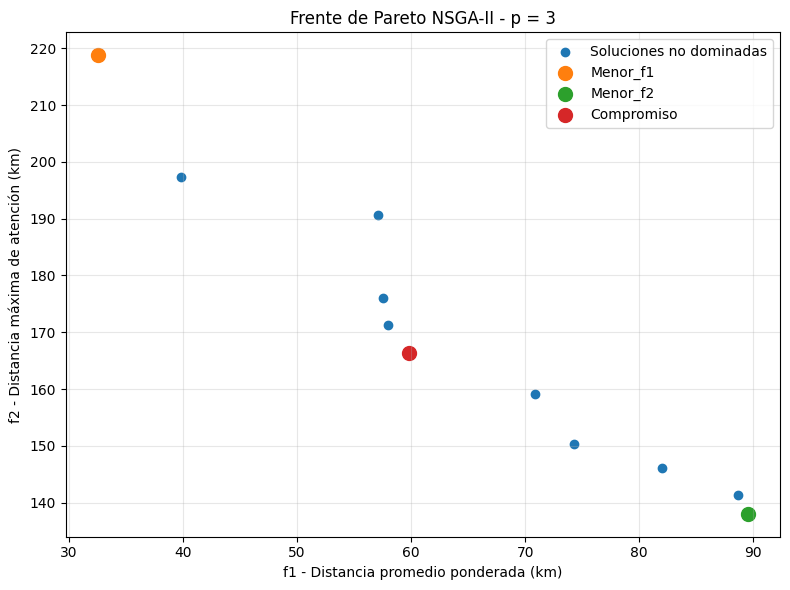

Figura guardada en: figures\frente_pareto_p3.png


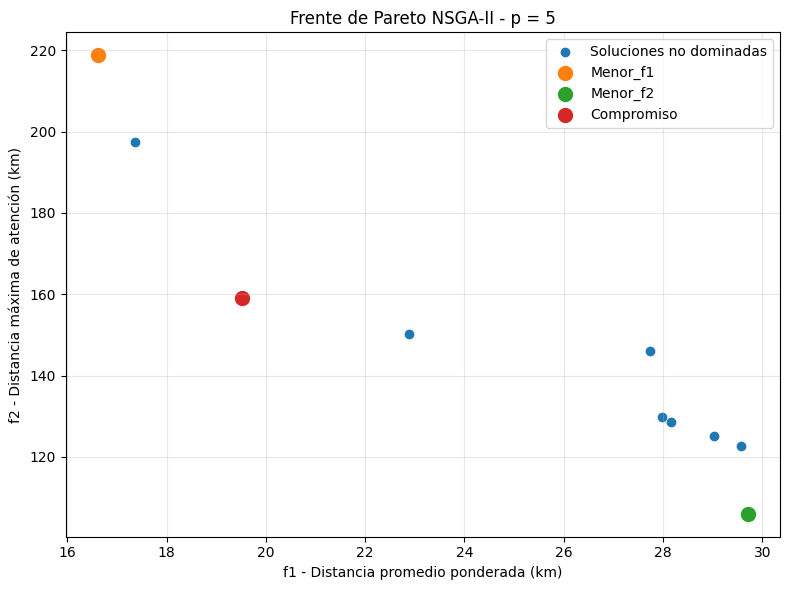

Figura guardada en: figures\frente_pareto_p5.png


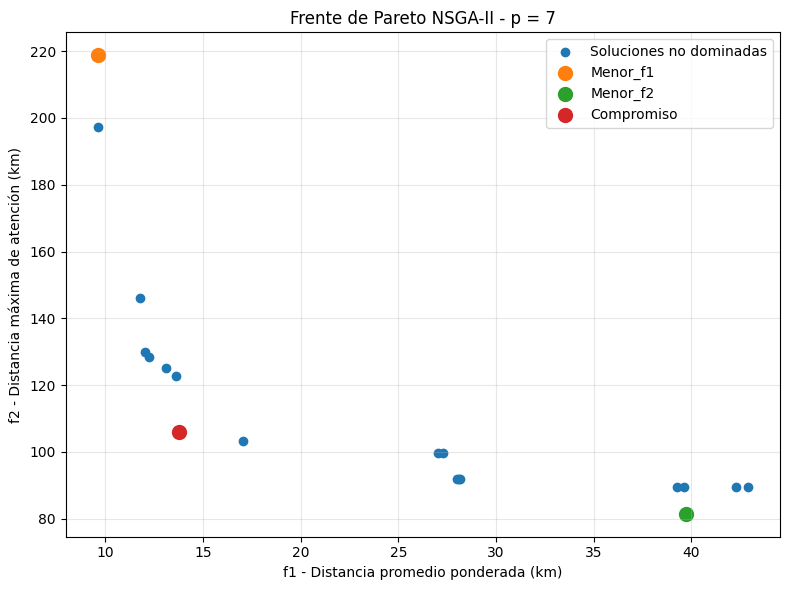

Figura guardada en: figures\frente_pareto_p7.png


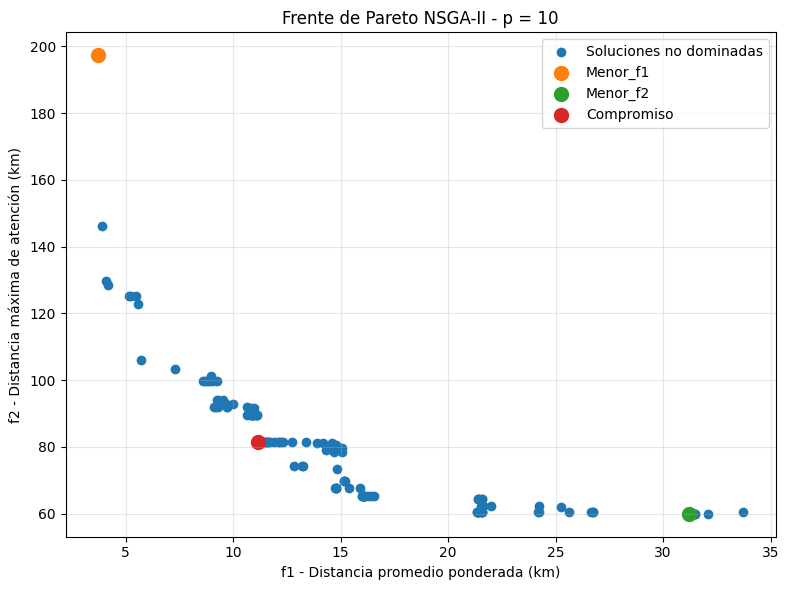

Figura guardada en: figures\frente_pareto_p10.png


In [83]:
# ============================================================
# GENERAR FRENTES DE PARETO
# ============================================================

for p in valores_p:

    graficar_frente_pareto(p)

In [84]:
# ============================================================
# TABLA RESUMEN DEL EXPERIMENTO MULTIOBJETIVO
# ============================================================

tabla_resumen_nsga2 = (
    df_representativas_nsga2[
        [
            "p",
            "tipo_solucion",
            "f1_km",
            "f2_km"
        ]
    ]
    .copy()
)

tabla_resumen_nsga2["f1_km"] = (
    tabla_resumen_nsga2["f1_km"]
    .round(4)
)

tabla_resumen_nsga2["f2_km"] = (
    tabla_resumen_nsga2["f2_km"]
    .round(4)
)

display(
    tabla_resumen_nsga2
)

,p,tipo_solucion,f1_km,f2_km
0,3,Menor_f1,32.5614,218.7570
1,3,Menor_f2,89.5045,138.0459
2,3,Compromiso,59.7711,166.3944
3,5,Menor_f1,16.6217,218.7570
4,5,Menor_f2,29.7023,106.0083
5,5,Compromiso,19.5093,159.1214
6,7,Menor_f1,9.6398,218.7570
7,7,Menor_f2,39.7127,81.4828
8,7,Compromiso,13.7626,106.0083
9,10,Menor_f1,3.7218,197.3279


# Optimización multiobjetivo con tres objetivos

En esta formulación se permitirá que el algoritmo determine automáticamente el número de centros de acopio a instalar.

Se mantendrán los dos objetivos utilizados anteriormente:

$$
f_1(x)=
\frac{
\sum_{i=1}^{n} P_i d_i^{\min}
}{
\sum_{i=1}^{n}P_i
}
$$

$$
f_2(x)=
\max_i d_i^{\min}
$$

y se incorporará un tercer objetivo correspondiente al número total de centros seleccionados:

$$
f_3(x)=
\sum_{j=1}^{43}x_j
$$

Por lo tanto, el problema se define como:

$$
\min \left(f_1(x),f_2(x),f_3(x)\right)
$$

sujeto a:

$$
3 \leq
\sum_{j=1}^{43}x_j
\leq 10
$$

Esta formulación permitirá estudiar simultáneamente el compromiso entre eficiencia logística, cobertura territorial y cantidad de infraestructura requerida.

## Inicialización factible para 3–10 centros

In [85]:
# ============================================================
# INICIALIZACIÓN FACTIBLE PARA TRES OBJETIVOS
# ============================================================

class MuestreoFactibleTresObjetivos(Sampling):

    def __init__(self, min_centros=3, max_centros=10):
        super().__init__()

        self.min_centros = min_centros
        self.max_centros = max_centros


    def _do(self, problem, n_samples, **kwargs):

        X = np.zeros(
            (n_samples, problem.n_var),
            dtype=bool
        )

        for i in range(n_samples):

            # Elegir aleatoriamente cuántos centros tendrá
            # el individuo dentro del rango permitido.
            cantidad_centros = np.random.randint(
                self.min_centros,
                self.max_centros + 1
            )

            indices = np.random.choice(
                problem.n_var,
                size=cantidad_centros,
                replace=False
            )

            X[i, indices] = True


        return X

In [86]:
# ============================================================
# REPARACIÓN PARA TRES OBJETIVOS
# ============================================================

class ReparacionRangoCentros(Repair):

    def __init__(self, min_centros=3, max_centros=10):
        super().__init__()

        self.min_centros = min_centros
        self.max_centros = max_centros


    def _do(self, problem, X, **kwargs):

        X = X.astype(bool)

        for i in range(len(X)):

            seleccionados = np.where(
                X[i]
            )[0]

            no_seleccionados = np.where(
                ~X[i]
            )[0]


            # ------------------------------------------------
            # Si existen demasiados centros
            # ------------------------------------------------

            if len(seleccionados) > self.max_centros:

                eliminar = np.random.choice(
                    seleccionados,
                    size=(
                        len(seleccionados)
                        - self.max_centros
                    ),
                    replace=False
                )

                X[i, eliminar] = False


            # ------------------------------------------------
            # Si existen menos de 3 centros
            # ------------------------------------------------

            elif len(seleccionados) < self.min_centros:

                agregar = np.random.choice(
                    no_seleccionados,
                    size=(
                        self.min_centros
                        - len(seleccionados)
                    ),
                    replace=False
                )

                X[i, agregar] = True


        return X

## Función con tres objetivos

In [87]:
# ============================================================
# FUNCIÓN DE TRES OBJETIVOS
# ============================================================

def calcular_objetivos_tres(indices_centros):
    """
    Calcula los tres objetivos:

    f1: distancia promedio ponderada.
    f2: distancia máxima de atención.
    f3: número de centros seleccionados.
    """

    f1, f2 = calcular_objetivos_multiobjetivo(
        indices_centros
    )

    f3 = len(
        indices_centros
    )

    return (
        float(f1),
        float(f2),
        int(f3)
    )

In [88]:
# ============================================================
# VERIFICACIÓN DE LOS TRES OBJETIVOS
# ============================================================

indices_prueba_tres = [
    11, 32, 34
]

f1_prueba, f2_prueba, f3_prueba = (
    calcular_objetivos_tres(
        indices_prueba_tres
    )
)


print("============================================================")
print("VERIFICACIÓN DE LOS TRES OBJETIVOS")
print("============================================================")

print(
    f"f1 - Distancia promedio ponderada: "
    f"{f1_prueba:.4f} km"
)

print(
    f"f2 - Distancia máxima de atención: "
    f"{f2_prueba:.4f} km"
)

print(
    f"f3 - Número de centros: "
    f"{f3_prueba}"
)

VERIFICACIÓN DE LOS TRES OBJETIVOS
f1 - Distancia promedio ponderada: 32.5614 km
f2 - Distancia máxima de atención: 218.7570 km
f3 - Número de centros: 3


## Definición del problema en PYMOO

In [89]:
# ============================================================
# PROBLEMA MULTIOBJETIVO DE TRES OBJETIVOS
# ============================================================

class ProblemaCentrosAcopioTresObjetivos(
    ElementwiseProblem
):

    def __init__(self):

        super().__init__(
            n_var=n_municipios,
            n_obj=3,
            n_ieq_constr=0,
            xl=0,
            xu=1,
            vtype=bool
        )


    def _evaluate(
        self,
        x,
        out,
        *args,
        **kwargs
    ):

        # Obtener los municipios seleccionados
        indices_centros = np.where(
            x
        )[0]


        # Calcular los tres objetivos
        f1, f2, f3 = calcular_objetivos_tres(
            indices_centros
        )


        out["F"] = [
            f1,
            f2,
            f3
        ]

## Configuración experimental

In [90]:
# ============================================================
# CONFIGURACIÓN DE NSGA-II - TRES OBJETIVOS
# ============================================================

POBLACION_NSGA2_3OBJ = 100
GENERACIONES_NSGA2_3OBJ = 200

PROB_CRUCE_NSGA2_3OBJ = 0.90

PROB_MUTACION_NSGA2_3OBJ = (
    1 / n_municipios
)

NUM_CORRIDAS_NSGA2_3OBJ = 30

SEMILLAS_NSGA2_3OBJ = list(
    range(NUM_CORRIDAS_NSGA2_3OBJ)
)


print("============================================================")
print("NSGA-II CON TRES OBJETIVOS")
print("============================================================")

print(
    f"Tamaño de población: "
    f"{POBLACION_NSGA2_3OBJ}"
)

print(
    f"Número de generaciones: "
    f"{GENERACIONES_NSGA2_3OBJ}"
)

print(
    f"Probabilidad de cruce: "
    f"{PROB_CRUCE_NSGA2_3OBJ}"
)

print(
    f"Probabilidad de mutación: "
    f"{PROB_MUTACION_NSGA2_3OBJ:.6f}"
)

print(
    f"Centros mínimos: 3"
)

print(
    f"Centros máximos: 10"
)

print(
    f"Número de corridas: "
    f"{NUM_CORRIDAS_NSGA2_3OBJ}"
)

print(
    f"Semillas: "
    f"{SEMILLAS_NSGA2_3OBJ}"
)

NSGA-II CON TRES OBJETIVOS
Tamaño de población: 100
Número de generaciones: 200
Probabilidad de cruce: 0.9
Probabilidad de mutación: 0.023256
Centros mínimos: 3
Centros máximos: 10
Número de corridas: 30
Semillas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


## Función de ejecución de NSGA-II

In [91]:
# ============================================================
# EJECUTAR NSGA-II CON TRES OBJETIVOS
# ============================================================

def ejecutar_nsga2_tres_objetivos(seed):

    problema = (
        ProblemaCentrosAcopioTresObjetivos()
    )


    algoritmo = NSGA2(

        pop_size=POBLACION_NSGA2_3OBJ,

        sampling=(
            MuestreoFactibleTresObjetivos(
                min_centros=3,
                max_centros=10
            )
        ),

        crossover=UX(
            prob=PROB_CRUCE_NSGA2_3OBJ
        ),

        mutation=BitflipMutation(
            prob=PROB_MUTACION_NSGA2_3OBJ
        ),

        repair=ReparacionRangoCentros(
            min_centros=3,
            max_centros=10
        ),

        eliminate_duplicates=True
    )


    resultado = minimize(

        problema,

        algoritmo,

        termination=(
            "n_gen",
            GENERACIONES_NSGA2_3OBJ
        ),

        seed=seed,

        verbose=False
    )


    return resultado

In [92]:
# ============================================================
# PRUEBA INICIAL - TRES OBJETIVOS
# ============================================================

resultado_3obj_prueba = (
    ejecutar_nsga2_tres_objetivos(
        seed=0
    )
)


print("============================================================")
print("PRUEBA DE NSGA-II CON TRES OBJETIVOS")
print("============================================================")

print(
    f"Número de soluciones no dominadas: "
    f"{len(resultado_3obj_prueba.F)}"
)

PRUEBA DE NSGA-II CON TRES OBJETIVOS
Número de soluciones no dominadas: 96


In [93]:
# ============================================================
# MOSTRAR FRENTE DE PARETO DE TRES OBJETIVOS
# ============================================================

for i, objetivos in enumerate(
    resultado_3obj_prueba.F
):

    f1 = objetivos[0]
    f2 = objetivos[1]
    f3 = int(
        round(objetivos[2])
    )

    print(
        f"Solución {i + 1}: "
        f"f1 = {f1:.4f} km | "
        f"f2 = {f2:.4f} km | "
        f"f3 = {f3} centros"
    )

Solución 1: f1 = 20.4873 km | f2 = 218.7570 km | f3 = 4 centros
Solución 2: f1 = 17.3524 km | f2 = 197.3279 km | f3 = 5 centros
Solución 3: f1 = 32.5614 km | f2 = 218.7570 km | f3 = 3 centros
Solución 4: f1 = 57.5356 km | f2 = 176.0972 km | f3 = 3 centros
Solución 5: f1 = 13.3978 km | f2 = 218.7570 km | f3 = 6 centros
Solución 6: f1 = 19.5093 km | f2 = 159.1214 km | f3 = 5 centros
Solución 7: f1 = 17.4953 km | f2 = 122.6982 km | f3 = 6 centros
Solución 8: f1 = 16.2854 km | f2 = 152.0517 km | f3 = 6 centros
Solución 9: f1 = 28.8394 km | f2 = 129.8046 km | f3 = 5 centros
Solución 10: f1 = 43.1198 km | f2 = 132.9849 km | f3 = 4 centros
Solución 11: f1 = 10.2630 km | f2 = 197.3279 km | f3 = 7 centros
Solución 12: f1 = 16.6217 km | f2 = 218.7570 km | f3 = 5 centros
Solución 13: f1 = 34.9584 km | f2 = 150.2774 km | f3 = 4 centros
Solución 14: f1 = 12.4198 km | f2 = 152.0517 km | f3 = 7 centros
Solución 15: f1 = 44.9404 km | f2 = 95.2291 km | f3 = 6 centros
Solución 16: f1 = 13.4868 km | f2 =

In [94]:
# ============================================================
# VERIFICAR RANGO DE CENTROS
# ============================================================

cardinalidades_3obj = []

for solucion in resultado_3obj_prueba.X:

    cantidad = int(
        np.sum(solucion)
    )

    cardinalidades_3obj.append(
        cantidad
    )


print(
    "Número de centros encontrados:",
    sorted(
        set(cardinalidades_3obj)
    )
)


restriccion_correcta = all(
    3 <= cantidad <= 10
    for cantidad in cardinalidades_3obj
)


print(
    "Todas las soluciones cumplen "
    "3 <= número de centros <= 10:",
    restriccion_correcta
)

Número de centros encontrados: [3, 4, 5, 6, 7, 8, 9, 10]
Todas las soluciones cumplen 3 <= número de centros <= 10: True


## Experimento completo de 30 corridas

In [95]:
# ============================================================
# EJECUCIÓN COMPLETA DE NSGA-II CON TRES OBJETIVOS
# ============================================================

resultados_nsga2_3obj = []

for seed in SEMILLAS_NSGA2_3OBJ:

    print(
        f"Ejecutando semilla {seed}"
    )

    resultado = ejecutar_nsga2_tres_objetivos(
        seed=seed
    )

    resultados_nsga2_3obj.append({
        "seed": seed,
        "numero_soluciones_no_dominadas": len(resultado.F),
        "resultado": resultado
    })


print("\n============================================================")
print("EJECUCIÓN COMPLETADA")
print("============================================================")

print(
    f"Total de corridas realizadas: "
    f"{len(resultados_nsga2_3obj)}"
)

Ejecutando semilla 0
Ejecutando semilla 1
Ejecutando semilla 2
Ejecutando semilla 3
Ejecutando semilla 4
Ejecutando semilla 5
Ejecutando semilla 6
Ejecutando semilla 7
Ejecutando semilla 8
Ejecutando semilla 9
Ejecutando semilla 10
Ejecutando semilla 11
Ejecutando semilla 12
Ejecutando semilla 13
Ejecutando semilla 14
Ejecutando semilla 15
Ejecutando semilla 16
Ejecutando semilla 17
Ejecutando semilla 18
Ejecutando semilla 19
Ejecutando semilla 20
Ejecutando semilla 21
Ejecutando semilla 22
Ejecutando semilla 23
Ejecutando semilla 24
Ejecutando semilla 25
Ejecutando semilla 26
Ejecutando semilla 27
Ejecutando semilla 28
Ejecutando semilla 29

EJECUCIÓN COMPLETADA
Total de corridas realizadas: 30


In [96]:
# ============================================================
# EXTRAER SOLUCIONES NO DOMINADAS
# ============================================================

filas_3obj = []

for registro in resultados_nsga2_3obj:

    seed = registro["seed"]
    resultado = registro["resultado"]

    for i, solucion in enumerate(
        resultado.X
    ):

        indices_centros = np.where(
            solucion
        )[0]

        centros = nombres_municipios[
            indices_centros
        ].tolist()

        f1 = float(
            resultado.F[i, 0]
        )

        f2 = float(
            resultado.F[i, 1]
        )

        f3 = int(
            round(
                resultado.F[i, 2]
            )
        )

        filas_3obj.append({
            "seed": seed,
            "solucion": i + 1,
            "f1_promedio_ponderado_km": f1,
            "f2_distancia_maxima_km": f2,
            "f3_numero_centros": f3,
            "indices_centros": indices_centros.tolist(),
            "centros": centros
        })


df_nsga2_3obj = pd.DataFrame(
    filas_3obj
)

print("============================================================")
print("SOLUCIONES EXTRAÍDAS")
print("============================================================")

print(
    f"Total de soluciones almacenadas: "
    f"{len(df_nsga2_3obj)}"
)

display(
    df_nsga2_3obj.head()
)

SOLUCIONES EXTRAÍDAS
Total de soluciones almacenadas: 2687


,seed,solucion,f1_promedio_ponderado_km,f2_distancia_maxima_km,f3_numero_centros,indices_centros,centros
0,0,1,59.771136,166.394431,3,"[11, 14, 34]","[González, Gustavo Díaz Ordaz, San Fernando]"
1,0,2,21.422552,197.327862,4,"[11, 21, 31, 34]","[González, Matamoros, Reynosa, San Fernando]"
2,0,3,16.621667,218.757001,5,"[11, 21, 32, 34, 39]","[González, Matamoros, Río Bravo, San Fernando,..."
3,0,4,32.561412,218.757001,3,"[11, 32, 34]","[González, Río Bravo, San Fernando]"
4,0,5,20.487329,218.757001,4,"[11, 21, 32, 34]","[González, Matamoros, Río Bravo, San Fernando]"


In [97]:
# ============================================================
# FRENTE CONSOLIDADO DE TRES OBJETIVOS
# ============================================================

df_frente_3obj = (
    df_nsga2_3obj
    .drop_duplicates(
        subset=[
            "f1_promedio_ponderado_km",
            "f2_distancia_maxima_km",
            "f3_numero_centros"
        ]
    )
    .sort_values(
        by=[
            "f3_numero_centros",
            "f1_promedio_ponderado_km"
        ]
    )
    .reset_index(drop=True)
)

print(
    f"Número de soluciones únicas: "
    f"{len(df_frente_3obj)}"
)

display(
    df_frente_3obj
)

Número de soluciones únicas: 685


,seed,solucion,f1_promedio_ponderado_km,f2_distancia_maxima_km,f3_numero_centros,indices_centros,centros
0,0,4,32.561412,218.757001,3,"[11, 32, 34]","[González, Río Bravo, San Fernando]"
1,0,33,39.789814,197.327862,3,"[11, 31, 34]","[González, Reynosa, San Fernando]"
2,1,71,57.082257,190.624696,3,"[7, 14, 39]","[Casas, Gustavo Díaz Ordaz, Valle Hermoso]"
3,1,2,57.535605,176.097157,3,"[14, 36, 39]","[Gustavo Díaz Ordaz, Soto la Marina, Valle Her..."
4,2,87,57.674530,186.503869,3,"[14, 39, 42]","[Gustavo Díaz Ordaz, Valle Hermoso, Xicoténcatl]"
...,...,...,...,...,...,...,...
680,5,82,26.435719,79.055282,10,"[2, 6, 11, 21, 22, 26, 29, 33, 34, 38]","[Altamira, Camargo, González, Matamoros, Ménde..."
681,2,79,26.580647,73.454405,10,"[0, 8, 10, 11, 14, 26, 34, 39, 40, 41]","[Abasolo, Ciudad Madero, Gómez Farías, Gonzále..."
682,2,57,29.733967,71.232803,10,"[0, 6, 8, 10, 11, 26, 34, 39, 40, 41]","[Abasolo, Camargo, Ciudad Madero, Gómez Farías..."
683,5,93,34.802274,74.208543,10,"[2, 6, 7, 8, 11, 21, 22, 26, 33, 38]","[Altamira, Camargo, Casas, Ciudad Madero, Gonz..."


In [98]:
# ============================================================
# MEJORES SOLUCIONES POR NÚMERO DE CENTROS
# ============================================================

resumen_por_centros = []

for numero_centros in sorted(
    df_frente_3obj["f3_numero_centros"].unique()
):

    df_p = df_frente_3obj[
        df_frente_3obj["f3_numero_centros"]
        == numero_centros
    ]

    menor_f1 = df_p.loc[
        df_p[
            "f1_promedio_ponderado_km"
        ].idxmin()
    ]

    menor_f2 = df_p.loc[
        df_p[
            "f2_distancia_maxima_km"
        ].idxmin()
    ]

    resumen_por_centros.append({
        "numero_centros": numero_centros,
        "menor_f1_km":
            menor_f1[
                "f1_promedio_ponderado_km"
            ],
        "f2_asociado_km":
            menor_f1[
                "f2_distancia_maxima_km"
            ],
        "menor_f2_km":
            menor_f2[
                "f2_distancia_maxima_km"
            ],
        "f1_asociado_km":
            menor_f2[
                "f1_promedio_ponderado_km"
            ]
    })


df_resumen_3obj = pd.DataFrame(
    resumen_por_centros
)

display(
    df_resumen_3obj.round(4)
)

,numero_centros,menor_f1_km,f2_asociado_km,menor_f2_km,f1_asociado_km
0,3,32.5614,218.7570,138.0459,89.5045
1,4,20.4873,218.7570,125.2327,54.2841
2,5,16.6217,218.7570,106.0083,29.7023
3,6,12.7804,218.7570,95.2291,41.3434
4,7,9.6398,218.7570,81.4828,39.8122
5,8,6.5049,197.3279,77.8516,42.7399
6,9,4.5419,197.3279,64.3055,33.4717
7,10,3.7921,197.3279,64.3055,21.3976


In [99]:
# ============================================================
# GUARDAR RESULTADOS DE TRES OBJETIVOS
# ============================================================

df_nsga2_3obj.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "resultados_nsga2_3_objetivos.csv"
    ),
    index=False
)

df_frente_3obj.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "frente_pareto_3_objetivos.csv"
    ),
    index=False
)

df_resumen_3obj.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "resumen_nsga2_3_objetivos.csv"
    ),
    index=False
)

print(
    "Resultados de tres objetivos guardados correctamente."
)

Resultados de tres objetivos guardados correctamente.


In [100]:
# ============================================================
# MEJORA AL INCREMENTAR EL NÚMERO DE CENTROS
# ============================================================

df_mejoras_centros = df_resumen_3obj.copy()

# ------------------------------------------------------------
# Mejora absoluta de f1
# ------------------------------------------------------------

df_mejoras_centros[
    "mejora_f1_km"
] = (
    df_mejoras_centros[
        "menor_f1_km"
    ]
    .shift(1)
    -
    df_mejoras_centros[
        "menor_f1_km"
    ]
)


# ------------------------------------------------------------
# Mejora absoluta de f2
# ------------------------------------------------------------

df_mejoras_centros[
    "mejora_f2_km"
] = (
    df_mejoras_centros[
        "menor_f2_km"
    ]
    .shift(1)
    -
    df_mejoras_centros[
        "menor_f2_km"
    ]
)


# ------------------------------------------------------------
# Mejora porcentual de f1
# ------------------------------------------------------------

df_mejoras_centros[
    "mejora_f1_porcentaje"
] = (
    df_mejoras_centros[
        "mejora_f1_km"
    ]
    /
    df_mejoras_centros[
        "menor_f1_km"
    ]
    .shift(1)
) * 100


# ------------------------------------------------------------
# Mejora porcentual de f2
# ------------------------------------------------------------

df_mejoras_centros[
    "mejora_f2_porcentaje"
] = (
    df_mejoras_centros[
        "mejora_f2_km"
    ]
    /
    df_mejoras_centros[
        "menor_f2_km"
    ]
    .shift(1)
) * 100


display(
    df_mejoras_centros.round(4)
)

,numero_centros,menor_f1_km,f2_asociado_km,menor_f2_km,f1_asociado_km,mejora_f1_km,mejora_f2_km,mejora_f1_porcentaje,mejora_f2_porcentaje
0,3,32.5614,218.7570,138.0459,89.5045,NaN,NaN,NaN,NaN
1,4,20.4873,218.7570,125.2327,54.2841,12.0741,12.8132,37.0810,9.2819
2,5,16.6217,218.7570,106.0083,29.7023,3.8657,19.2245,18.8685,15.3510
3,6,12.7804,218.7570,95.2291,41.3434,3.8413,10.7792,23.1102,10.1683
4,7,9.6398,218.7570,81.4828,39.8122,3.1406,13.7463,24.5734,14.4350
5,8,6.5049,197.3279,77.8516,42.7399,3.1349,3.6312,32.5203,4.4564
6,9,4.5419,197.3279,64.3055,33.4717,1.9630,13.5461,30.1769,17.3999
7,10,3.7921,197.3279,64.3055,21.3976,0.7499,0.0000,16.5098,0.0000


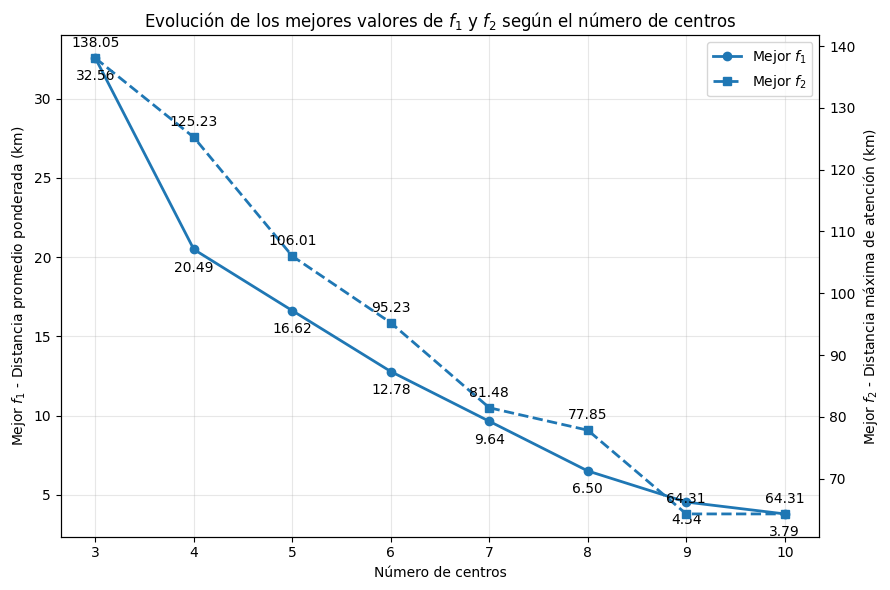

Figura guardada en: figures\evolucion_f1_f2_numero_centros.png


In [101]:
# ============================================================
# FIGURA: EVOLUCIÓN DEL MEJOR f1 Y MEJOR f2
# SEGÚN EL NÚMERO DE CENTROS
# ============================================================

fig, ax1 = plt.subplots(
    figsize=(9, 6)
)

# ------------------------------------------------------------
# Eje X
# ------------------------------------------------------------

x = df_resumen_3obj[
    "numero_centros"
]


# ------------------------------------------------------------
# Primer eje Y: mejor f1
# ------------------------------------------------------------

linea_f1 = ax1.plot(
    x,
    df_resumen_3obj["menor_f1_km"],
    marker="o",
    linewidth=2,
    label="Mejor $f_1$"
)

ax1.set_xlabel(
    "Número de centros"
)

ax1.set_ylabel(
    "Mejor $f_1$ - Distancia promedio ponderada (km)"
)

ax1.set_xticks(
    x
)

ax1.grid(
    True,
    alpha=0.3
)


# ------------------------------------------------------------
# Segundo eje Y: mejor f2
# ------------------------------------------------------------

ax2 = ax1.twinx()

linea_f2 = ax2.plot(
    x,
    df_resumen_3obj["menor_f2_km"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Mejor $f_2$"
)

ax2.set_ylabel(
    "Mejor $f_2$ - Distancia máxima de atención (km)"
)


# ------------------------------------------------------------
# Título
# ------------------------------------------------------------

plt.title(
    "Evolución de los mejores valores de $f_1$ y $f_2$ "
    "según el número de centros"
)


# ------------------------------------------------------------
# Leyenda conjunta
# ------------------------------------------------------------

lineas = linea_f1 + linea_f2

etiquetas = [
    linea.get_label()
    for linea in lineas
]

ax1.legend(
    lineas,
    etiquetas,
    loc="upper right"
)


# ------------------------------------------------------------
# Etiquetas numéricas de f1
# ------------------------------------------------------------

for x_i, y_i in zip(
    x,
    df_resumen_3obj["menor_f1_km"]
):

    ax1.annotate(
        f"{y_i:.2f}",
        (x_i, y_i),
        textcoords="offset points",
        xytext=(0, -16),
        ha="center"
    )


# ------------------------------------------------------------
# Etiquetas numéricas de f2
# ------------------------------------------------------------

for x_i, y_i in zip(
    x,
    df_resumen_3obj["menor_f2_km"]
):

    ax2.annotate(
        f"{y_i:.2f}",
        (x_i, y_i),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )


# ------------------------------------------------------------
# Ajustar diseño
# ------------------------------------------------------------

fig.tight_layout()


# ------------------------------------------------------------
# Guardar figura
# ------------------------------------------------------------

ruta_figura = os.path.join(
    RUTA_FIGURAS,
    "evolucion_f1_f2_numero_centros.png"
)

plt.savefig(
    ruta_figura,
    dpi=300,
    bbox_inches="tight"
)


# ------------------------------------------------------------
# Mostrar figura
# ------------------------------------------------------------

plt.show()

print(
    f"Figura guardada en: {ruta_figura}"
)

## Análisis marginal del número de centros

Para evaluar el beneficio obtenido al incrementar el número de centros de acopio, se calculará la mejora absoluta y porcentual de los mejores valores de $f_1$ y $f_2$ al pasar de una configuración con $k-1$ centros a otra con $k$ centros.

Este análisis permitirá identificar si el incremento en el número de instalaciones continúa produciendo mejoras importantes en los objetivos considerados o si los beneficios comienzan a disminuir conforme aumenta la cantidad de centros.

In [102]:
# ============================================================
# ANÁLISIS MARGINAL DEL NÚMERO DE CENTROS
# ============================================================

df_mejoras_centros = df_resumen_3obj.copy()


# ------------------------------------------------------------
# Mejora absoluta de f1
# ------------------------------------------------------------

df_mejoras_centros["mejora_f1_km"] = (
    df_mejoras_centros["menor_f1_km"].shift(1)
    - df_mejoras_centros["menor_f1_km"]
)


# ------------------------------------------------------------
# Mejora porcentual de f1
# ------------------------------------------------------------

df_mejoras_centros["mejora_f1_porcentaje"] = (
    df_mejoras_centros["mejora_f1_km"]
    / df_mejoras_centros["menor_f1_km"].shift(1)
) * 100


# ------------------------------------------------------------
# Mejora absoluta de f2
# ------------------------------------------------------------

df_mejoras_centros["mejora_f2_km"] = (
    df_mejoras_centros["menor_f2_km"].shift(1)
    - df_mejoras_centros["menor_f2_km"]
)


# ------------------------------------------------------------
# Mejora porcentual de f2
# ------------------------------------------------------------

df_mejoras_centros["mejora_f2_porcentaje"] = (
    df_mejoras_centros["mejora_f2_km"]
    / df_mejoras_centros["menor_f2_km"].shift(1)
) * 100


# ------------------------------------------------------------
# Mostrar resultados
# ------------------------------------------------------------

columnas_mostrar = [
    "numero_centros",
    "menor_f1_km",
    "mejora_f1_km",
    "mejora_f1_porcentaje",
    "menor_f2_km",
    "mejora_f2_km",
    "mejora_f2_porcentaje"
]

display(
    df_mejoras_centros[
        columnas_mostrar
    ].round(4)
)

,numero_centros,menor_f1_km,mejora_f1_km,mejora_f1_porcentaje,menor_f2_km,mejora_f2_km,mejora_f2_porcentaje
0,3,32.5614,NaN,NaN,138.0459,NaN,NaN
1,4,20.4873,12.0741,37.0810,125.2327,12.8132,9.2819
2,5,16.6217,3.8657,18.8685,106.0083,19.2245,15.3510
3,6,12.7804,3.8413,23.1102,95.2291,10.7792,10.1683
4,7,9.6398,3.1406,24.5734,81.4828,13.7463,14.4350
5,8,6.5049,3.1349,32.5203,77.8516,3.6312,4.4564
6,9,4.5419,1.9630,30.1769,64.3055,13.5461,17.3999
7,10,3.7921,0.7499,16.5098,64.3055,0.0000,0.0000


In [103]:
# ============================================================
# IDENTIFICAR ESTANCAMIENTO EN f2
# ============================================================

sin_mejora_f2 = df_mejoras_centros[
    df_mejoras_centros["mejora_f2_km"] <= 0
]

print("============================================================")
print("ANÁLISIS DE ESTANCAMIENTO DE f2")
print("============================================================")

if len(sin_mejora_f2) > 0:

    display(
        sin_mejora_f2[
            [
                "numero_centros",
                "menor_f2_km",
                "mejora_f2_km"
            ]
        ]
    )

else:

    print(
        "No se identificaron configuraciones "
        "sin mejora en f2."
    )

ANÁLISIS DE ESTANCAMIENTO DE f2


,numero_centros,menor_f2_km,mejora_f2_km
7,10,64.305504,0.0


In [104]:
# ============================================================
# TABLA RESUMEN DEL BENEFICIO MARGINAL
# ============================================================

tabla_mejora_marginal = (
    df_mejoras_centros[
        [
            "numero_centros",
            "mejora_f1_km",
            "mejora_f1_porcentaje",
            "mejora_f2_km",
            "mejora_f2_porcentaje"
        ]
    ]
    .copy()
)

display(
    tabla_mejora_marginal.round(2)
)

,numero_centros,mejora_f1_km,mejora_f1_porcentaje,mejora_f2_km,mejora_f2_porcentaje
0,3,NaN,NaN,NaN,NaN
1,4,12.07,37.08,12.81,9.28
2,5,3.87,18.87,19.22,15.35
3,6,3.84,23.11,10.78,10.17
4,7,3.14,24.57,13.75,14.43
5,8,3.13,32.52,3.63,4.46
6,9,1.96,30.18,13.55,17.40
7,10,0.75,16.51,0.00,0.00


## Interpretación del análisis marginal

El análisis marginal mostró que el incremento del número de centros produce mejoras en la distancia promedio ponderada $f_1$ y, en general, en la distancia máxima de atención $f_2$. Sin embargo, la magnitud de estas mejoras no es constante.

La mayor reducción absoluta de $f_1$ se presentó al pasar de 3 a 4 centros, con una disminución de 12.07 km. Posteriormente, las mejoras absolutas fueron menores, aunque continuaron siendo positivas hasta alcanzar 10 centros.

En el caso de $f_2$, la reducción de la distancia máxima de atención fue variable entre las diferentes configuraciones. Al pasar de 9 a 10 centros no se observó una mejora adicional, ya que ambos escenarios alcanzaron un valor mínimo de 64.31 km.

Estos resultados indican que los beneficios obtenidos al incrementar el número de centros no son uniformes. En particular, una configuración de 9 centros puede considerarse relevante desde el punto de vista de la cobertura territorial, debido a que incorporar un décimo centro no redujo la mejor distancia máxima de atención encontrada.